### Annotate chimaera on subclusters

First plots show that it is not good enough to transfer celltypes from whole atlas. Instead, subcluster celltypes are transfered from PCA integration of ONLY the relevant celltypes from both Atlas and Chimaera datasets (see notebooks 1_gut_chimaera and 1_haem_chimaera)

In [1]:
suppressPackageStartupMessages({
    library(dplyr)
    library(ggplot2)
    library(Matrix)
    library(scran)
    library(Rtsne)
    library(BiocParallel)
    require(irlba)
    library(batchelor)
    library(stringr)
    library(gridExtra) ## can be replaced by just cowplot
    library(cowplot)
    library(M3C)
    library(Seurat)
    library(tidyr)
})

### I/O

In [2]:
out_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/"
big_meta_in = paste0(out_folder, 'big_meta_mapping.tab')
pcs_in = paste0(out_folder, 'corrected_pc_complete.csv')

In [3]:
big_meta = read.table(big_meta_in, header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
big_meta$origin <- sapply(strsplit(big_meta$cell,"_"), `[`, 1) 
big_pcs = as.data.frame(read.csv(pcs_in, header=T, row.names=1,sep=","))
big_pcs$cell <- rownames(big_pcs)

In [4]:
head(big_meta)
head(big_pcs)

,cell,sample,stage,barcode,sequencing.batch,stripped,doublet,theiler,doub.density,cluster,⋯,endo_gutX,endo_gutY,endo_gutDPT,endo_gutCluster,weight,stage.mapped,celltype.mapped,closest.cell,tdTom,origin
,<chr>,<chr>,<chr>,<chr>,<int>,<lgl>,<lgl>,<chr>,<dbl>,<int>,⋯,<dbl>,<dbl>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>
1,atlas_cell_1,atlas_1,E6.5,AAAGGCCTCCACAA,1,FALSE,FALSE,TS9,0.0431142,2,⋯,NA,NA,NA,NA,1,NA,NA,NA,NA,atlas
2,atlas_cell_2,atlas_1,E6.5,AACAAACTCGCCTT,1,FALSE,FALSE,TS9,1.1297133,12,⋯,NA,NA,NA,NA,2,NA,NA,NA,NA,atlas
3,atlas_cell_5,atlas_1,E6.5,AACAGAGAATCAGC,1,FALSE,FALSE,TS9,0.1121205,3,⋯,NA,NA,NA,NA,5,NA,NA,NA,NA,atlas
4,atlas_cell_6,atlas_1,E6.5,AACATATGAATCGC,1,FALSE,FALSE,TS9,1.2547088,1,⋯,NA,NA,NA,NA,6,NA,NA,NA,NA,atlas
5,atlas_cell_8,atlas_1,E6.5,AACCGATGGCTTCC,1,FALSE,FALSE,TS9,1.3457586,2,⋯,NA,NA,NA,NA,8,NA,NA,NA,NA,atlas
6,atlas_cell_9,atlas_1,E6.5,AACGTGTGCTCTAT,1,FALSE,FALSE,TS9,1.1463686,2,⋯,NA,NA,NA,NA,9,NA,NA,NA,NA,atlas


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,⋯,V42,V43,V44,V45,V46,V47,V48,V49,V50,cell
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
atlas_cell_1,-0.04657868,0.028434859,0.002200190,-0.04386366,-0.03805917,0.06118444,0.026915712,-0.07511555,-0.07152037,0.03894618,⋯,-0.006901177,0.0008529858,-0.0100648500,-0.028187634,-0.005661704,0.0005857092,-0.012123328,-0.024716693,0.001382783,atlas_cell_1
atlas_cell_2,-0.04604056,0.031341237,-0.010801791,-0.05261751,-0.02700275,0.03752020,-0.021332570,-0.03466139,-0.05819388,0.02770551,⋯,-0.013086402,0.0178953929,0.0121801585,-0.006837621,-0.004202107,-0.0103396314,-0.020488842,-0.026676866,-0.003924181,atlas_cell_2
atlas_cell_5,0.13659841,0.009862427,-0.124731825,0.19166052,0.00457191,0.05572577,-0.020537490,-0.05367119,-0.04992352,0.01859462,⋯,0.005806552,0.0154387914,0.0229570547,-0.023933380,0.005264673,0.0061753542,-0.028318131,-0.012491913,0.006828581,atlas_cell_5
atlas_cell_6,-0.04573350,0.044054239,-0.015267300,-0.05331560,-0.05330568,0.02373019,-0.001153916,-0.07340319,-0.09795753,0.01243688,⋯,-0.009596227,0.0209064426,0.0007855576,-0.013926063,-0.008593263,-0.0096130180,-0.016256747,-0.010229567,0.006702206,atlas_cell_6
atlas_cell_8,-0.04110981,0.051916864,-0.019344393,-0.05028709,-0.05354881,0.02387607,0.012861237,-0.07820564,-0.09854164,0.01518366,⋯,-0.008917086,0.0098477217,-0.0006584951,-0.009451405,-0.002410473,0.0006633903,-0.005922365,-0.006203519,0.022474979,atlas_cell_8
atlas_cell_9,-0.03505198,0.038322027,-0.006152927,-0.04125056,-0.04238199,0.01831386,0.018844281,-0.07929482,-0.09674417,0.01798179,⋯,-0.019405341,0.0307211576,-0.0102055870,-0.013316734,-0.009898733,-0.0006457211,-0.008670421,-0.003797094,0.010328407,atlas_cell_9


In [5]:
colnames(big_meta)

[1] "cell"                "sample"              "stage"              
 [4] "barcode"             "sequencing.batch"    "stripped"           
 [7] "doublet"             "theiler"             "doub.density"       
[10] "cluster"             "cluster.sub"         "cluster.stage"      
[13] "cluster.theiler"     "celltype"            "colour"             
[16] "umapX"               "umapY"               "haem_gephiX"        
[19] "haem_gephiY"         "haem_subclust"       "endo_gephiX"        
[22] "endo_gephiY"         "endo_trajectoryName" "endo_trajectoryDPT" 
[25] "endo_gutX"           "endo_gutY"           "endo_gutDPT"        
[28] "endo_gutCluster"     "weight"              "stage.mapped"       
[31] "celltype.mapped"     "closest.cell"        "tdTom"              
[34] "origin"

## Mapping - does not work correctly (for haem) --> done in 1_gut_chimaera and 1_haem_chimaera

### Gut

In [77]:
# Isolate celltypes of gut subclusters 
celltypes = big_meta %>% filter(endo_gutCluster != 'NA') %>% .$celltype %>% unique() # = only gut appaerently
cells = big_meta %>% filter(endo_gutCluster != 'NA' | celltype.mapped %in% celltypes) %>% .$cell

sub_meta = big_meta %>% filter(cell %in% cells)
sub_pcs = big_pcs %>% filter(cell %in% cells)

# split atlas and chimaera
atlas_cells = sub_meta %>% filter(origin=='atlas') %>% .$cell
atlas_pcs = sub_pcs %>% filter(cell %in% atlas_cells) %>% select(1:50)
atlas_meta = sub_meta %>% filter(cell %in% atlas_cells)
map_pcs = sub_pcs %>% filter(!cell %in% atlas_cells) %>% select(1:50) # keep only PC columns
map_meta = sub_meta %>% filter(!cell %in% atlas_cells) 

In [86]:
## Code for mapping:

getmode <- function(v, dist) {
  tab = table(v)
  #if tie, break to shortest distance
  if(sum(tab == max(tab)) > 1){
    tied = names(tab)[tab == max(tab)]
    sub = dist[v %in% tied]
    names(sub) = v[v %in% tied]
    return(names(sub)[which.min(sub)])
  } else {
    return(names(tab)[which.max(tab)])
  }
}

mnnMap = function(correct_atlas, atlas_meta, correct_map, map_meta, k_map = 10){
  require(BiocNeighbors)
  require(scran)
  
  knns = BiocNeighbors::queryKNN(correct_atlas, correct_map, k = k_map, get.index = TRUE, get.distance = FALSE)
  
  #get closest k matching cells
  k.mapped = t(apply(knns$index, 1, function(x) atlas_meta$cell[x]))
  celltypes = t(apply(k.mapped, 1, function(x) atlas_meta$celltype[match(x, atlas_meta$cell)]))
  gut_subclust = t(apply(k.mapped, 1, function(x) atlas_meta$endo_gutCluster[match(x, atlas_meta$cell)])) ## ADD HERE
  celltype.mapped = apply(celltypes, 1, function(x) getmode(x, 1:length(x)))
  gut_subclust.mapped = apply(gut_subclust, 1, function(x) getmode(x, 1:length(x))) ## ADD HERE
  
  out = lapply(1:length(celltype.mapped), function(x){
    list(cells.mapped = k.mapped[x,],
         celltype.mapped = celltype.mapped[x],
         gut_subclust.mapped = gut_subclust.mapped[x])     ## ADD HERE
  })
  
  names(out) = map_meta$cell

  return(out)
  
}

In [92]:
# Perform mapping:
mapping = mnnMap(atlas_pcs, atlas_meta, map_pcs, map_meta, k_map = 10)
  
  cn = substr(names(mapping), 5, nchar(names(mapping))) # remove 
  ct = sapply(mapping, function(x) x$celltype.mapped)
  cs = sapply(mapping, function(x) x$gut_subclust.mapped) ## ADD HERE
  closest = sapply(mapping, function(x) x$cells.mapped[1])
  
  out = data.frame(cell = cn, celltype.mapped = ct, closest.cell = closest, gut_subclust.mapped = cs) ## ADD HERE
  out$cell = rownames(out)
# save mapped celltypes
write.csv(out, paste0(out_folder, 'chimaera_gut_mapped.csv')) 

In [99]:
big_meta = merge(big_meta, out %>% select(cell, gut_subclust.mapped), by='cell', all.x = TRUE)

### Haem

In [100]:
colnames(big_meta)

[1] "cell"                "sample"              "stage"              
 [4] "barcode"             "sequencing.batch"    "stripped"           
 [7] "doublet"             "theiler"             "doub.density"       
[10] "cluster"             "cluster.sub"         "cluster.stage"      
[13] "cluster.theiler"     "celltype"            "colour"             
[16] "umapX"               "umapY"               "haem_gephiX"        
[19] "haem_gephiY"         "haem_subclust"       "endo_gephiX"        
[22] "endo_gephiY"         "endo_trajectoryName" "endo_trajectoryDPT" 
[25] "endo_gutX"           "endo_gutY"           "endo_gutDPT"        
[28] "endo_gutCluster"     "weight"              "stage.mapped"       
[31] "celltype.mapped"     "closest.cell"        "tdTom"              
[34] "origin"              "gut_subclust.mapped"

In [110]:
# Isolate celltypes of gut subclusters 
celltypes = big_meta %>% filter(haem_subclust != 'NA') %>% .$celltype %>% unique() # = only gut appaerently
cells = big_meta %>% filter(haem_subclust != 'NA' | celltype.mapped %in% celltypes) %>% .$cell

sub_meta = big_meta %>% filter(cell %in% cells)
sub_pcs = big_pcs %>% filter(cell %in% cells)

# split atlas and chimaera
atlas_cells = sub_meta %>% filter(origin=='atlas') %>% .$cell
atlas_pcs = sub_pcs %>% filter(cell %in% atlas_cells) %>% select(1:50)
atlas_meta = sub_meta %>% filter(cell %in% atlas_cells)
map_pcs = sub_pcs %>% filter(!cell %in% atlas_cells) %>% select(1:50) # keep only PC columns
map_meta = sub_meta %>% filter(!cell %in% atlas_cells) 

In [111]:
## Code for mapping:

getmode <- function(v, dist) {
  tab = table(v)
  #if tie, break to shortest distance
  if(sum(tab == max(tab)) > 1){
    tied = names(tab)[tab == max(tab)]
    sub = dist[v %in% tied]
    names(sub) = v[v %in% tied]
    return(names(sub)[which.min(sub)])
  } else {
    return(names(tab)[which.max(tab)])
  }
}

mnnMap = function(correct_atlas, atlas_meta, correct_map, map_meta, k_map = 10){
  require(BiocNeighbors)
  require(scran)
  
  knns = BiocNeighbors::queryKNN(correct_atlas, correct_map, k = k_map, get.index = TRUE, get.distance = FALSE)
  
  #get closest k matching cells
  k.mapped = t(apply(knns$index, 1, function(x) atlas_meta$cell[x]))
  celltypes = t(apply(k.mapped, 1, function(x) atlas_meta$celltype[match(x, atlas_meta$cell)]))
  haem_subclust = t(apply(k.mapped, 1, function(x) atlas_meta$haem_subclust[match(x, atlas_meta$cell)])) ## ADD HERE
  celltype.mapped = apply(celltypes, 1, function(x) getmode(x, 1:length(x)))
  haem_subclust.mapped = apply(haem_subclust, 1, function(x) getmode(x, 1:length(x))) ## ADD HERE
  
  out = lapply(1:length(celltype.mapped), function(x){
    list(cells.mapped = k.mapped[x,],
         celltype.mapped = celltype.mapped[x],
         haem_subclust.mapped = haem_subclust.mapped[x])     ## ADD HERE
  })
  
  names(out) = map_meta$cell

  return(out)
  
}

In [124]:
# Perform mapping:
mapping = mnnMap(atlas_pcs, atlas_meta, map_pcs, map_meta, k_map = 10)
  
  cn = substr(names(mapping), 5, nchar(names(mapping))) # remove 
  ct = sapply(mapping, function(x) x$celltype.mapped)
  cs = sapply(mapping, function(x) x$haem_subclust.mapped) ## ADD HERE
  closest = sapply(mapping, function(x) x$cells.mapped[1])
  
  out = data.frame(cell = cn, celltype.mapped = ct, closest.cell = closest, haem_subclust.mapped = cs) ## ADD HERE
  out$cell = rownames(out)
# save mapped celltypes
write.csv(out, paste0(out_folder, 'chimaera_haem_mapped.csv')) 

In [125]:
big_meta = merge(big_meta, out %>% select(cell, haem_subclust.mapped), by='cell', all.x = TRUE)

In [127]:
write.csv(big_meta, paste0(out_folder, 'big_meta_mapping_plus.csv')) 

## Analyse mapping

In [135]:
umap_in = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/big_umap.csv"
umap = read.csv(umap_in)
big_meta = merge(big_meta, umap, by='cell')

In [136]:
tail(big_meta)

,cell,sample,stage,barcode,sequencing.batch,stripped,doublet,theiler,doub.density,cluster,⋯,weight,stage.mapped,celltype.mapped,closest.cell,tdTom,origin,gut_subclust.mapped,haem_subclust.mapped,umap_1,umap_2
,<chr>,<chr>,<chr>,<chr>,<int>,<lgl>,<lgl>,<chr>,<dbl>,<int>,⋯,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
153515,chim_cell_9991,mixl_2,E8.5,ATGTCTTAGAAATTCG,1,FALSE,FALSE,NA,NA,NA,⋯,149322,E8.25,Forebrain/Midbrain/Hindbrain,atlas_cell_69810,pos,chim,NA,NA,3.6534836,0.317363
153516,chim_cell_9993,mixl_2,E8.5,ATGTCTTCAGGACTTT,1,FALSE,FALSE,NA,NA,NA,⋯,149324,E8.25,ExE mesoderm,atlas_cell_95608,pos,chim,NA,NA,-1.4902902,10.026352
153517,chim_cell_9994,mixl_2,E8.5,ATGTCTTCAGGTATGG,1,FALSE,FALSE,NA,NA,NA,⋯,149325,E8.25,Erythroid2,atlas_cell_32454,pos,chim,NA,BP2,6.7257347,13.986918
153518,chim_cell_9997,mixl_2,E8.5,ATGTCTTTCGTGTTCC,1,FALSE,FALSE,NA,NA,NA,⋯,149328,E8.25,Def. endoderm,atlas_cell_18440,pos,chim,NA,NA,0.2601617,-6.019359
153519,chim_cell_9998,mixl_2,E8.5,ATTACCTAGAGTGGCT,1,FALSE,FALSE,NA,NA,NA,⋯,149329,E8.5,Paraxial mesoderm,atlas_cell_96463,pos,chim,NA,NA,-8.6056510,13.039355
153520,chim_cell_9999,mixl_2,E8.5,ATTACCTAGCCTGCCA,1,FALSE,FALSE,NA,NA,NA,⋯,149330,E8.5,Forebrain/Midbrain/Hindbrain,atlas_cell_96020,pos,chim,NA,NA,3.5704486,4.460979


In [132]:
chim = big_meta %>% filter(origin == 'chim')
# haem
meta = chim %>% filter(haem_subclust.mapped != 'NA')

pdf3 = table(meta$haem_subclust.mapped, meta$tdTom)
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))

p1 = ggplot(data = pdf3, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas haem_subclust", y = "Fraction of cells") +
  ggtitle("all pools chimeras") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$haem_subclust.mapped)[order(unique(meta$haem_subclust.mapped))])

# gut
meta = chim %>% filter(gut_subclust.mapped != 'NA')

pdf3 = table(meta$gut_subclust.mapped, meta$tdTom)
pdf3 = as.data.frame(sweep(pdf3, 2, colSums(pdf3), "/"))

p2 = ggplot(data = pdf3, mapping = aes(x = Var1, y = Freq, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("pos" = "red", "neg" = "black"), 
                    labels = c("pos" = "Tomato+", "neg" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas haem_subclust", y = "Fraction of cells") +
  ggtitle("all pools chimeras") +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",
        axis.title.x = element_blank()) +
  scale_x_discrete(breaks = unique(meta$gut_subclust.mapped)[order(unique(meta$gut_subclust.mapped))])


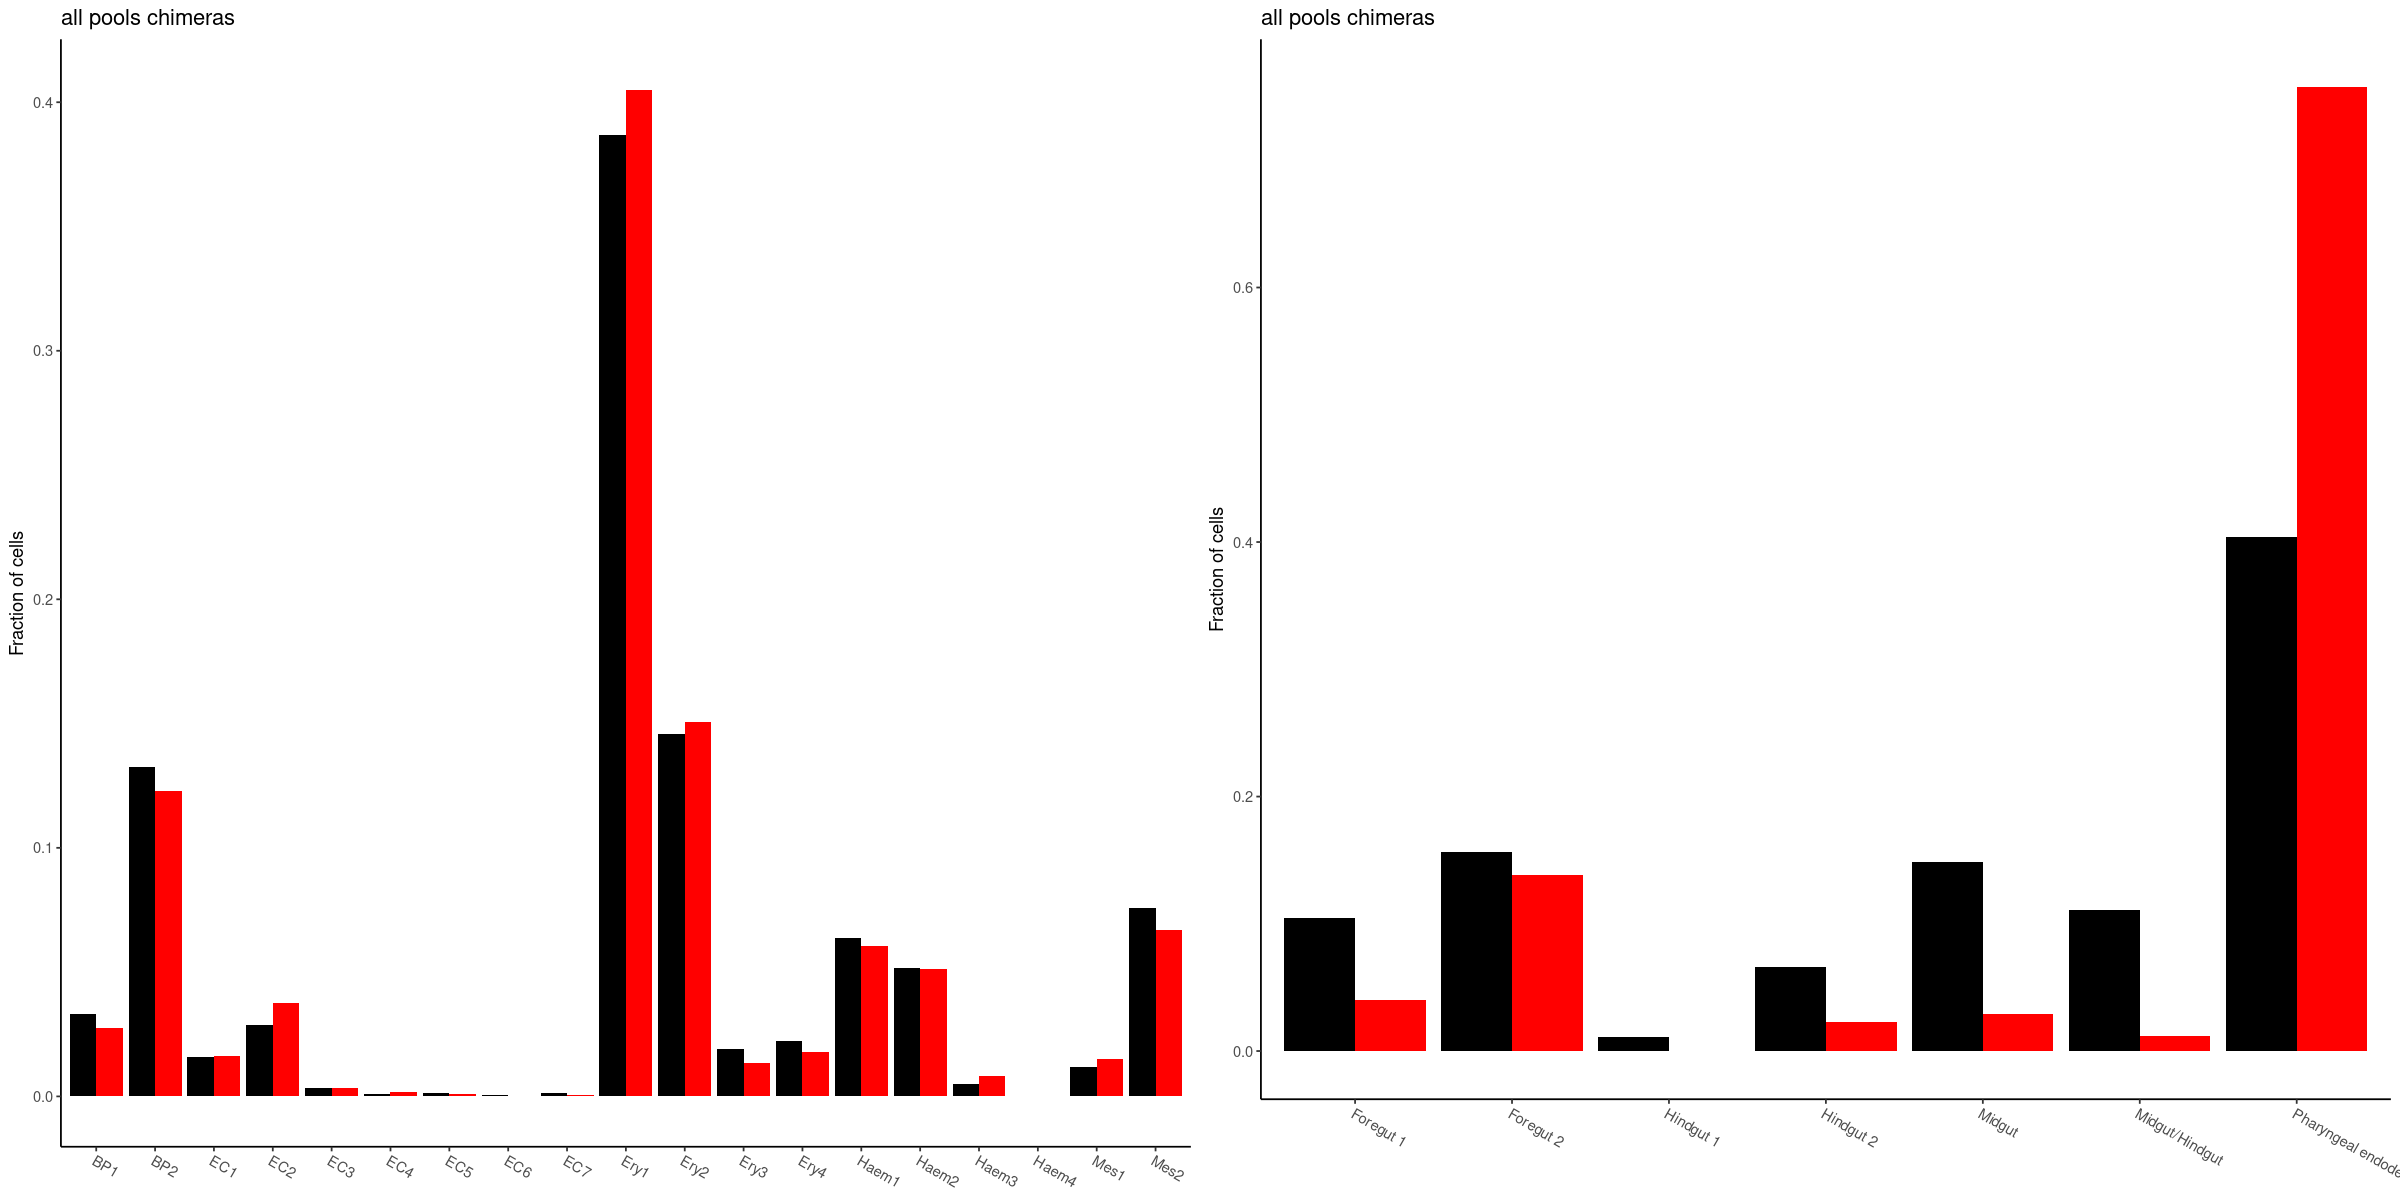

In [133]:
options(repr.plot.width = 20, repr.plot.height = 10)
grid.arrange(p1, p2, ncol =2)

In [134]:
colnames(big_meta)

[1] "cell"                 "sample"               "stage"               
 [4] "barcode"              "sequencing.batch"     "stripped"            
 [7] "doublet"              "theiler"              "doub.density"        
[10] "cluster"              "cluster.sub"          "cluster.stage"       
[13] "cluster.theiler"      "celltype"             "colour"              
[16] "umapX"                "umapY"                "haem_gephiX"         
[19] "haem_gephiY"          "haem_subclust"        "endo_gephiX"         
[22] "endo_gephiY"          "endo_trajectoryName"  "endo_trajectoryDPT"  
[25] "endo_gutX"            "endo_gutY"            "endo_gutDPT"         
[28] "endo_gutCluster"      "weight"               "stage.mapped"        
[31] "celltype.mapped"      "closest.cell"         "tdTom"               
[34] "origin"               "gut_subclust.mapped"  "haem_subclust.mapped"

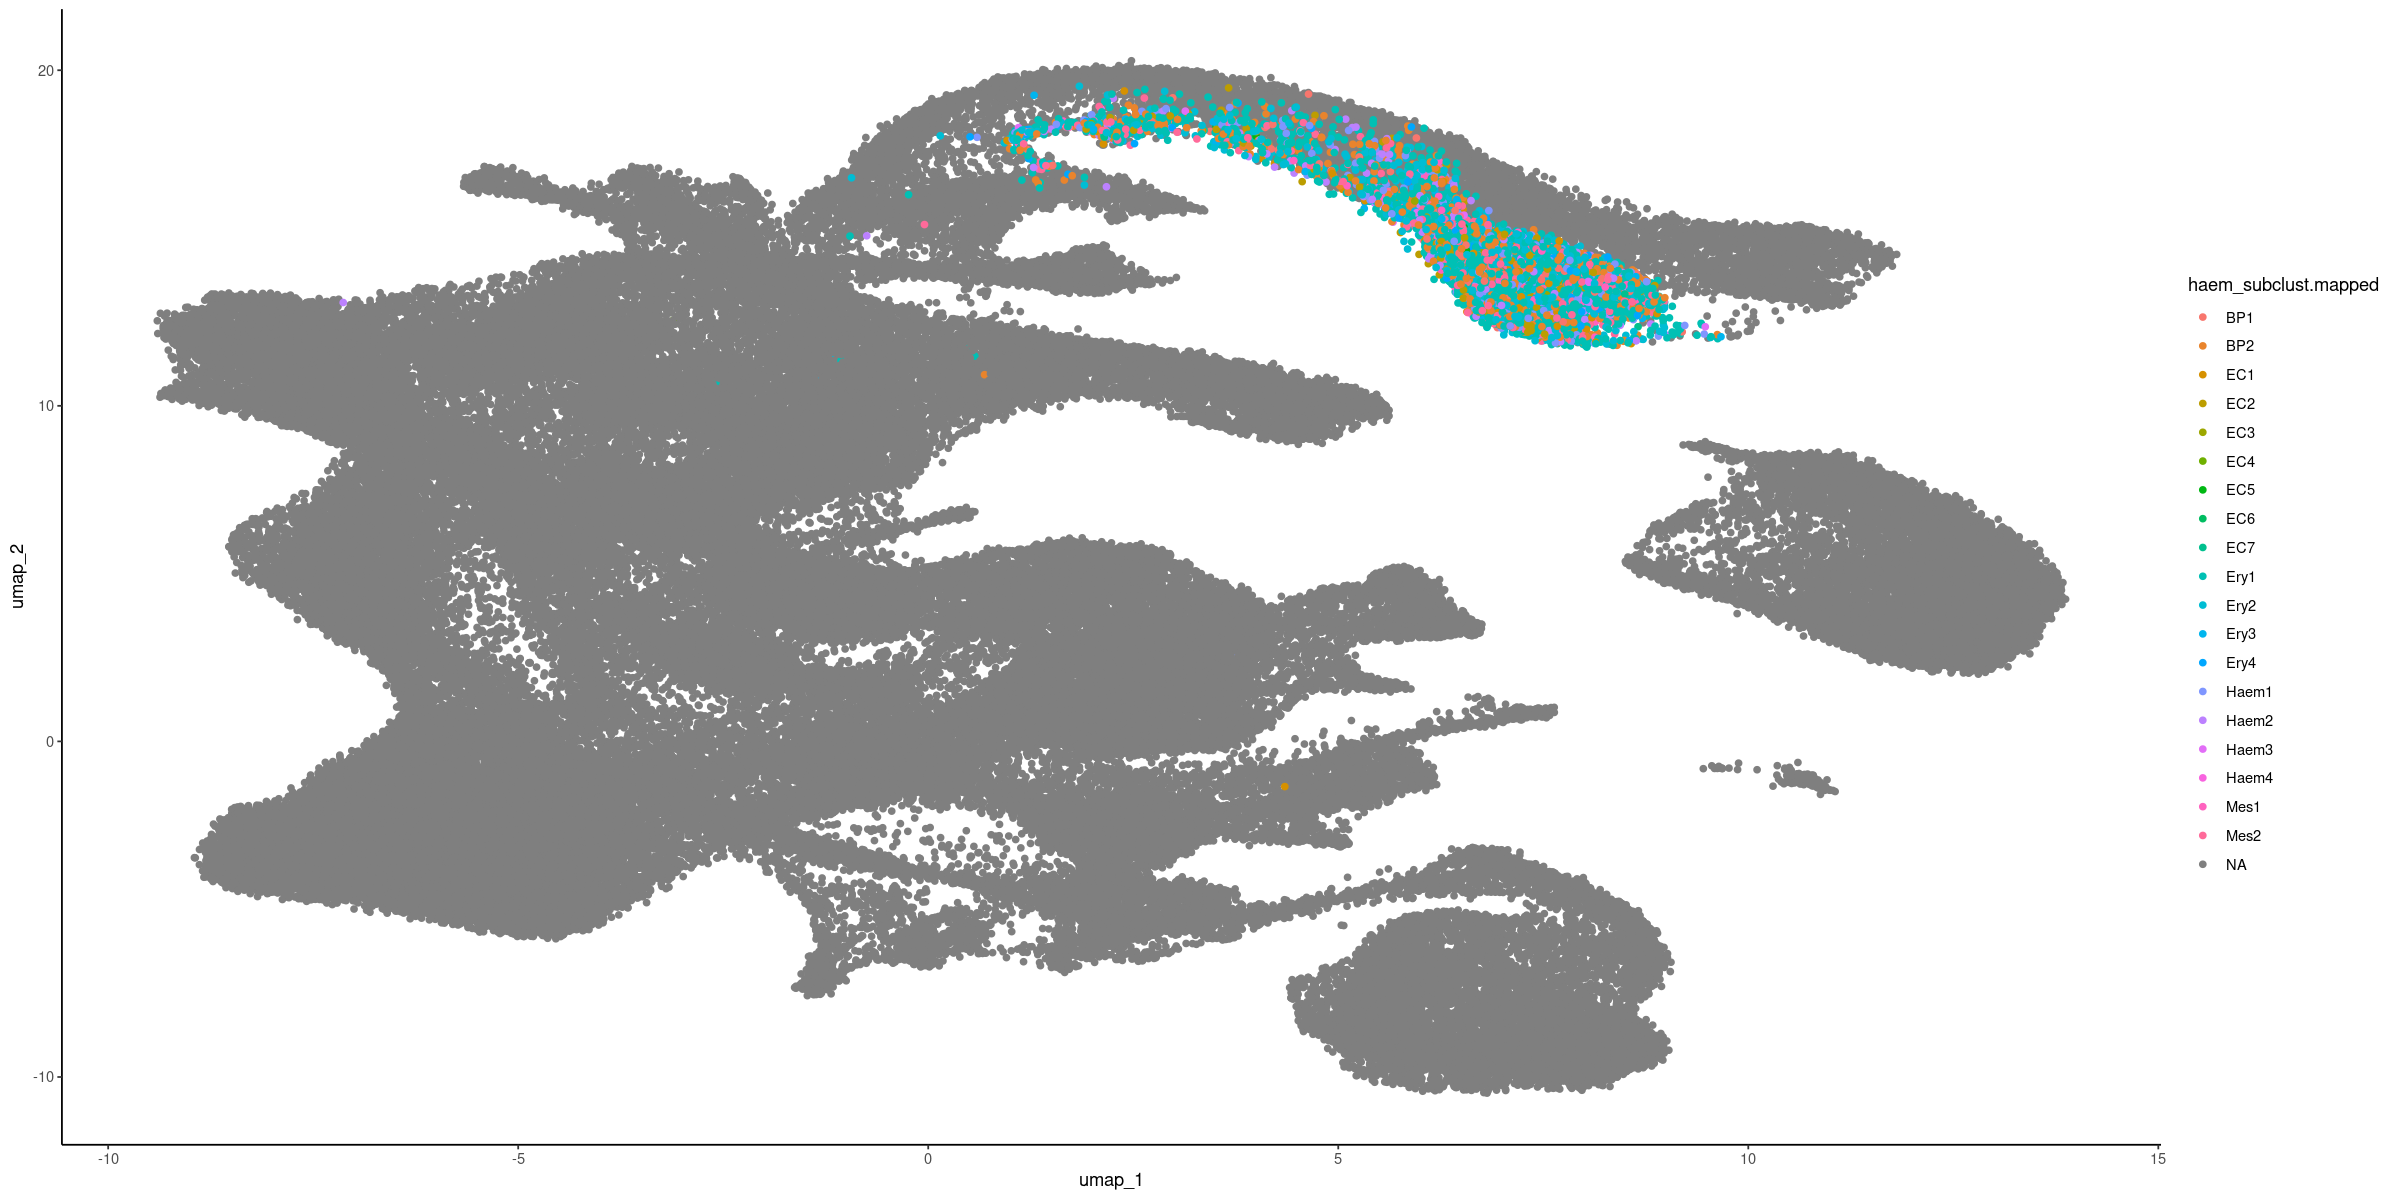

In [138]:
ggplot(big_meta, aes(umap_1, umap_2, color=haem_subclust.mapped)) + geom_point() + theme_classic()

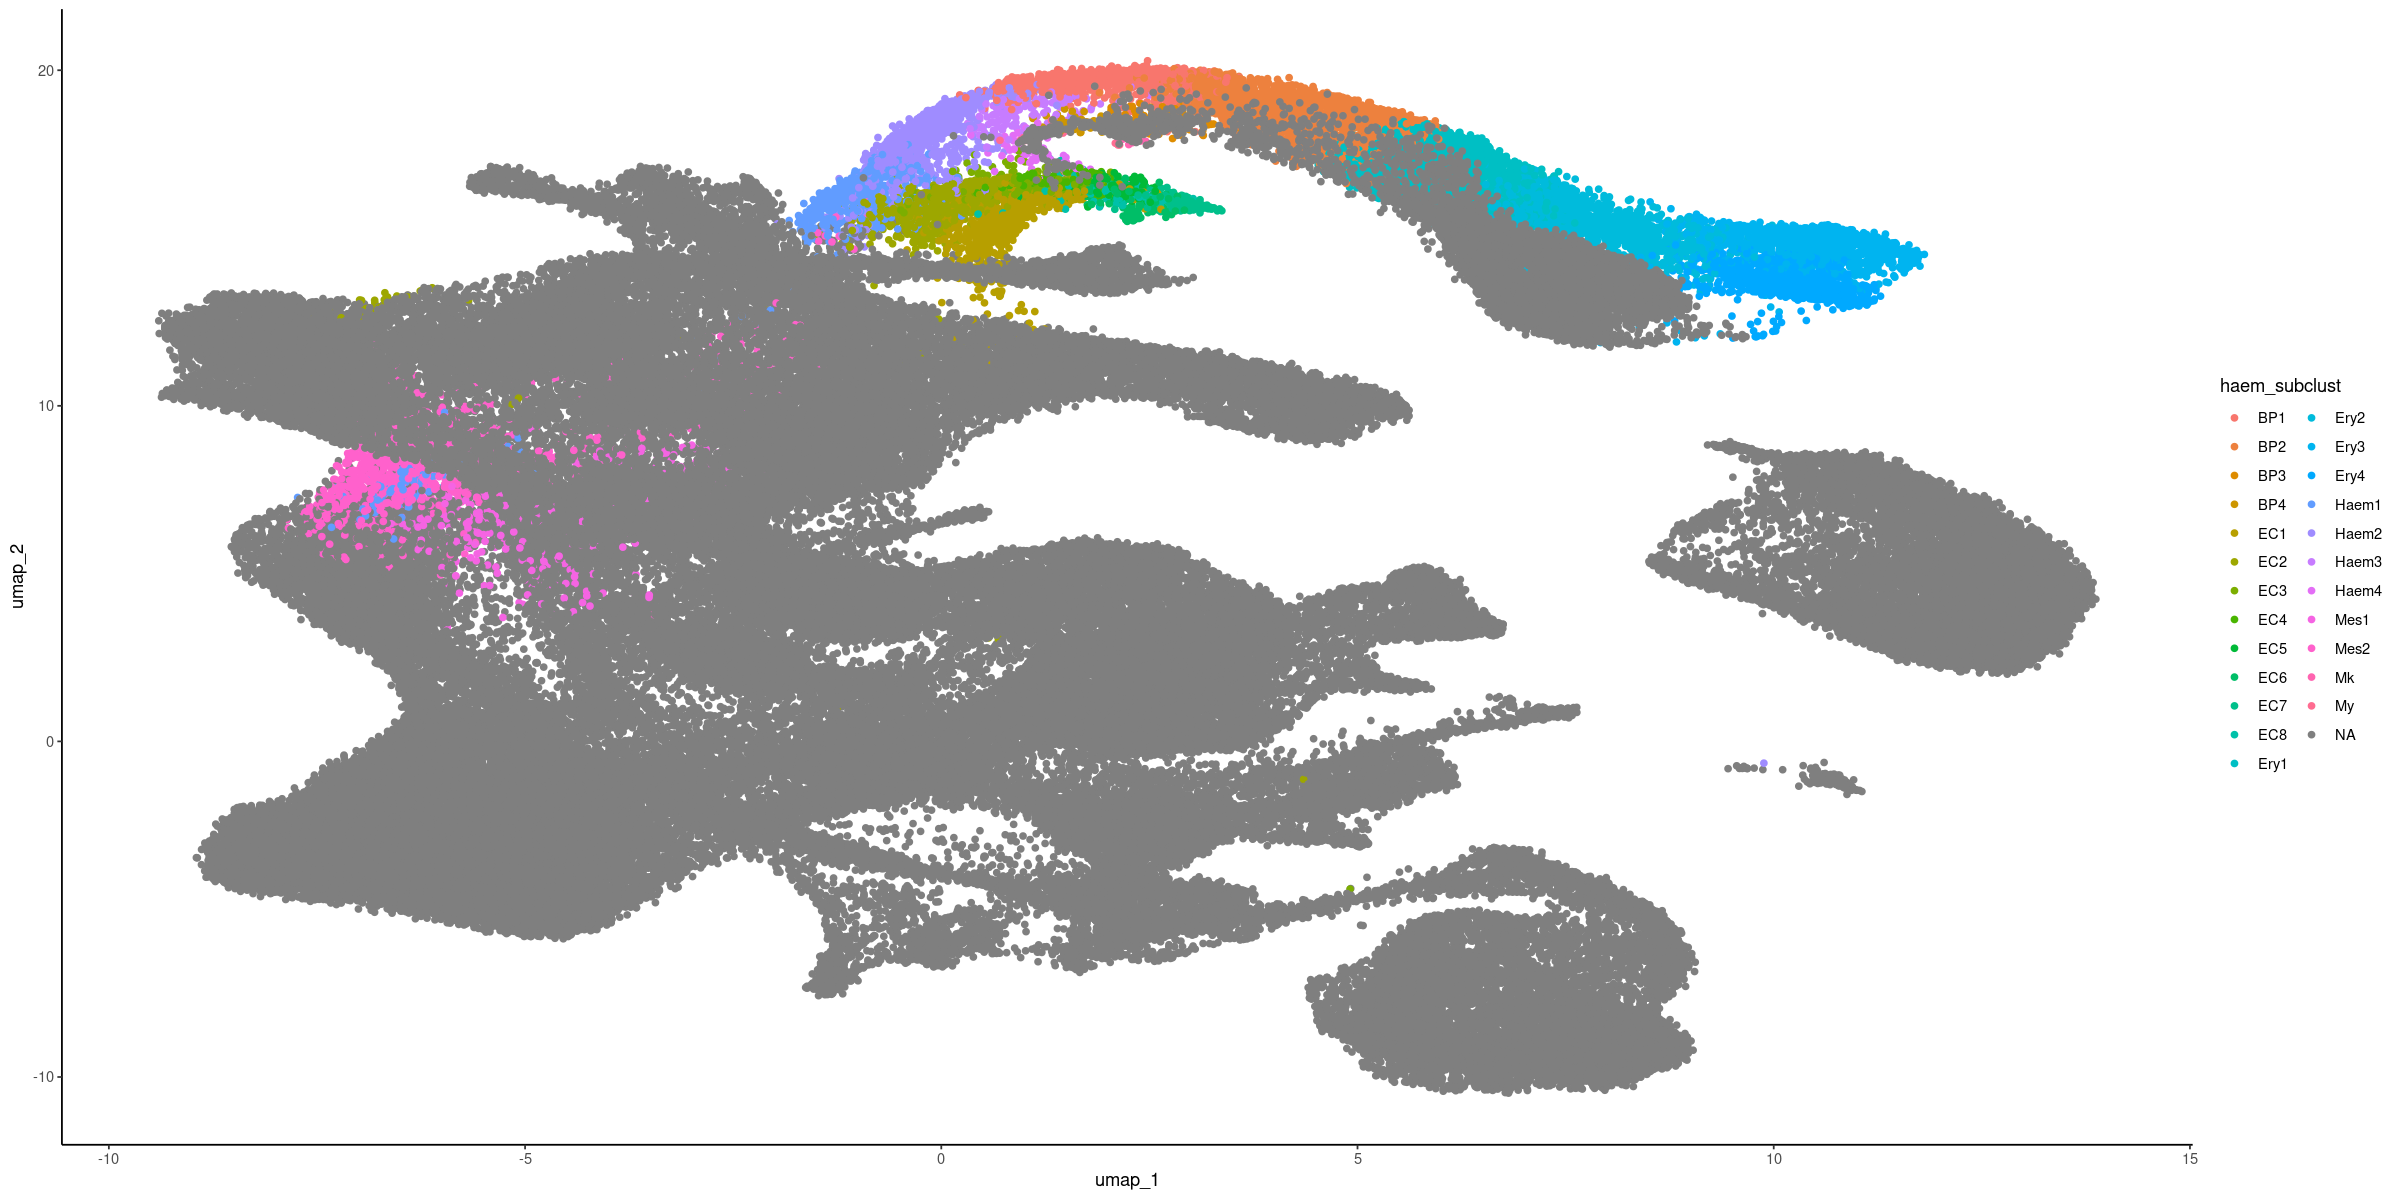

In [139]:
ggplot(big_meta, aes(umap_1, umap_2, color=haem_subclust)) + geom_point() + theme_classic()

In [140]:
haem_meta = read.table("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/haem/big_meta_mapping.tab", header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")

In [143]:
haem_meta = merge(haem_meta, umap, by='cell')

In [144]:
head(haem_meta)

,cell,sample,stage,barcode,sequencing.batch,stripped,doublet,theiler,doub.density,cluster,⋯,endo_gutDPT,endo_gutCluster,tdTom,weight,stage.mapped,celltype.mapped,closest.cell,haem_subclust.mapped,umap_1,umap_2
,<chr>,<chr>,<chr>,<chr>,<int>,<lgl>,<lgl>,<chr>,<dbl>,<int>,⋯,<lgl>,<lgl>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
1,atlas_cell_100006,atlas_29,E8.5,GACTGTGAGGACAG,3,FALSE,FALSE,TS12,0.14106887,18,⋯,NA,NA,NA,100006,NA,NA,NA,NA,9.5633960,14.56291
2,atlas_cell_100015,atlas_29,E8.5,GACTTTACTGGATC,3,FALSE,FALSE,TS12,0.12287684,18,⋯,NA,NA,NA,100015,NA,NA,NA,NA,10.8262610,13.85060
3,atlas_cell_100020,atlas_29,E8.5,GAGAAATGCCACAA,3,FALSE,FALSE,TS12,0.14642354,18,⋯,NA,NA,NA,100020,NA,NA,NA,NA,10.4237670,13.86316
4,atlas_cell_100032,atlas_29,E8.5,GAGATAGATACTCT,3,FALSE,FALSE,TS12,0.00000000,19,⋯,NA,NA,NA,100032,NA,NA,NA,NA,-0.5520838,15.73733
5,atlas_cell_100040,atlas_29,E8.5,GAGATGCTCTGTAG,3,FALSE,FALSE,TS12,0.12200878,14,⋯,NA,NA,NA,100040,NA,NA,NA,NA,7.9917850,15.79309
6,atlas_cell_100048,atlas_29,E8.5,GAGCAGGAACTCAG,3,FALSE,FALSE,TS12,0.03726561,19,⋯,NA,NA,NA,100048,NA,NA,NA,NA,0.7470909,15.76978


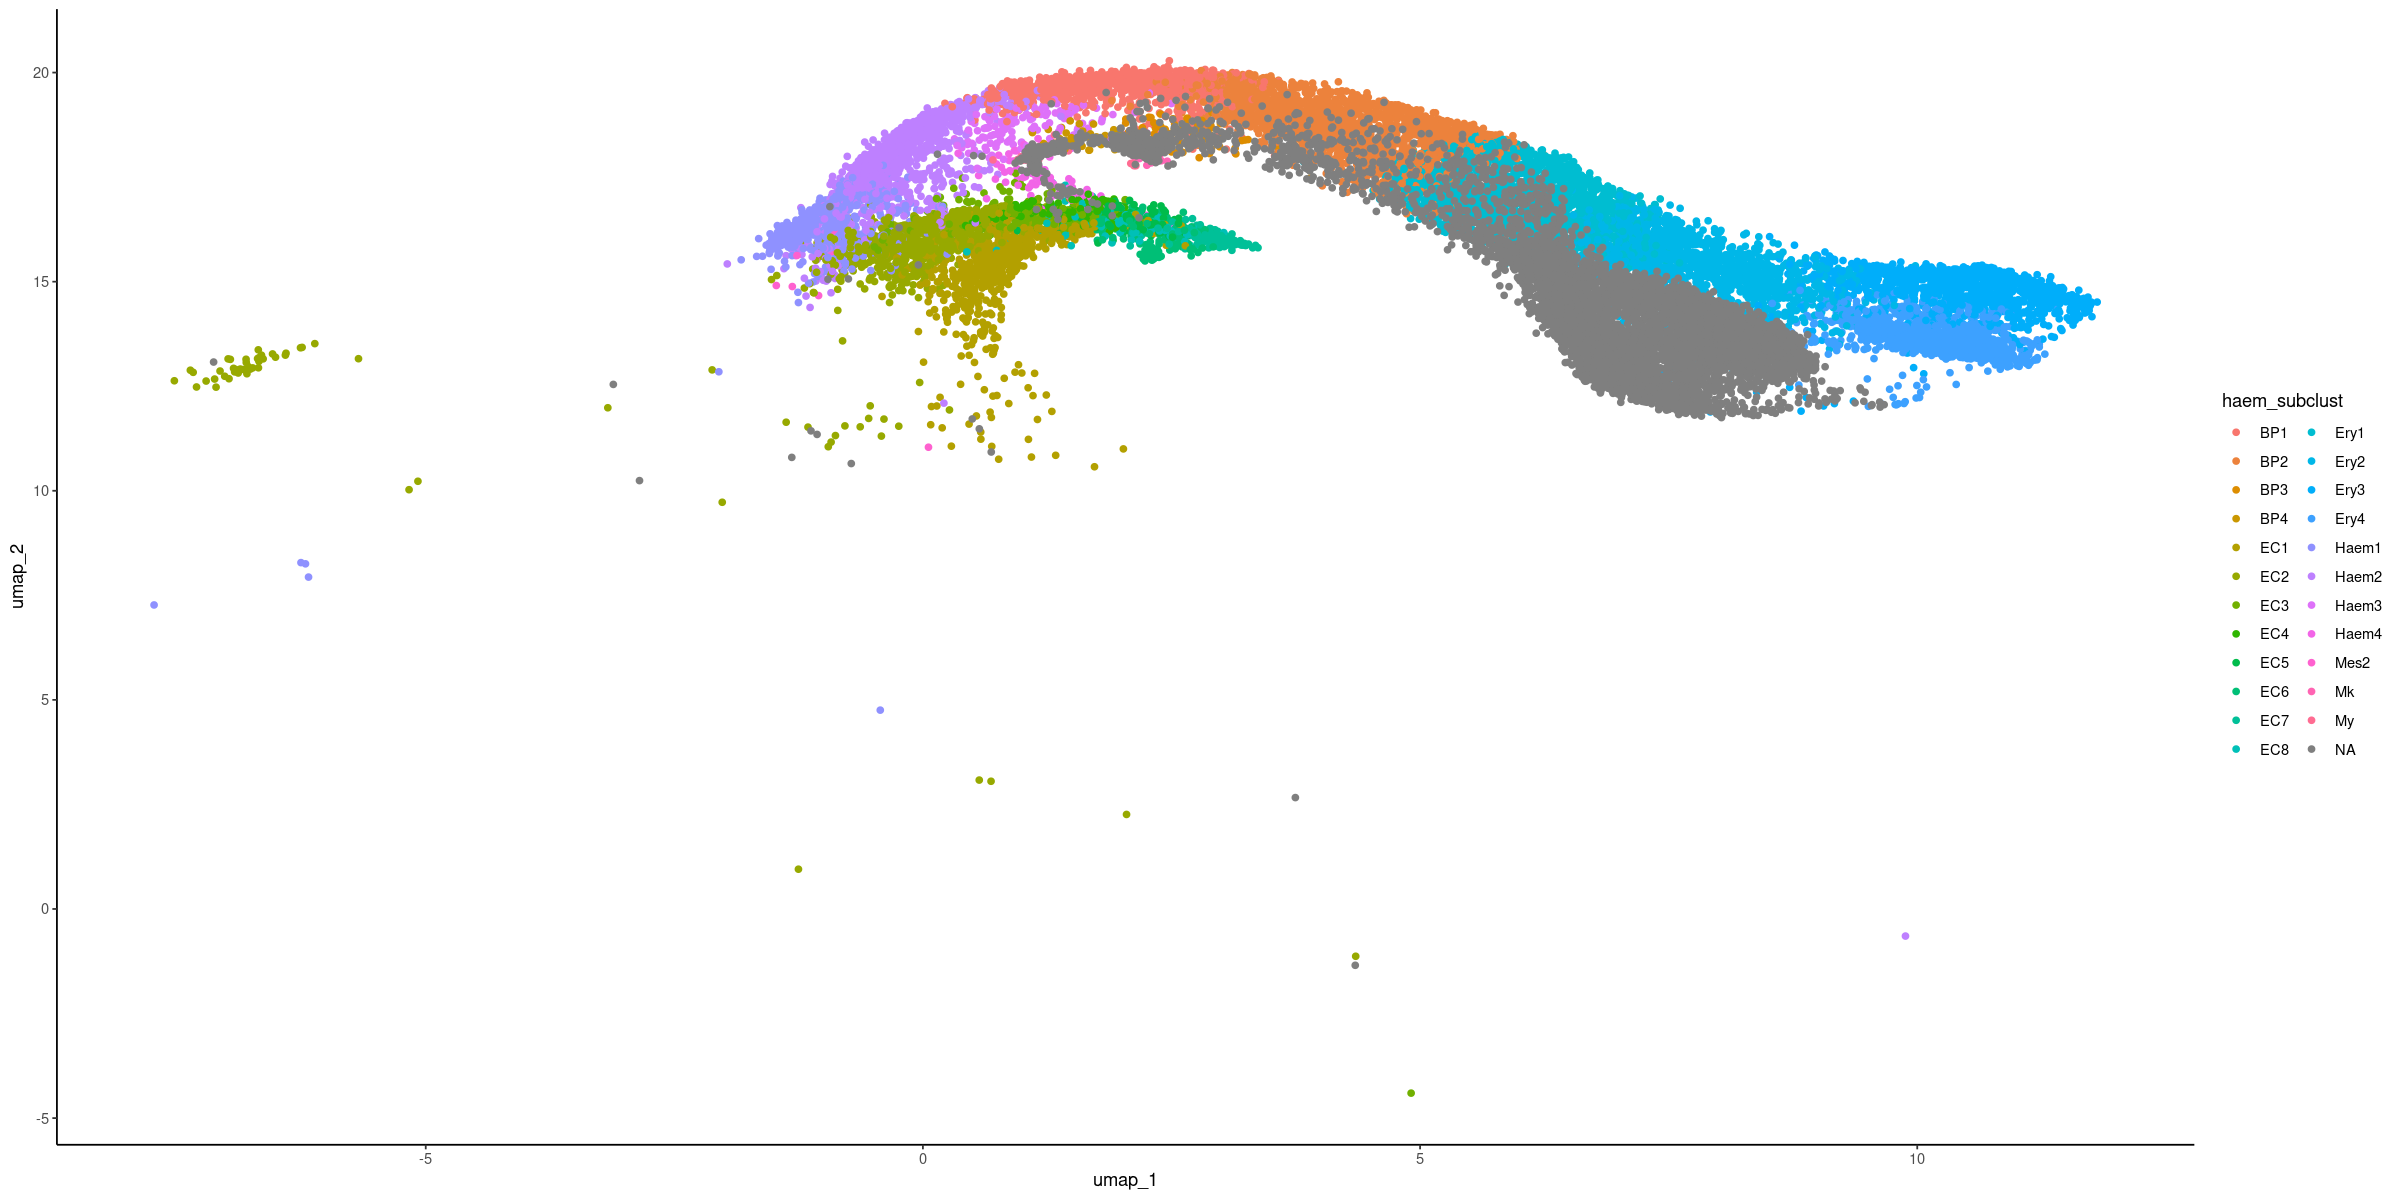

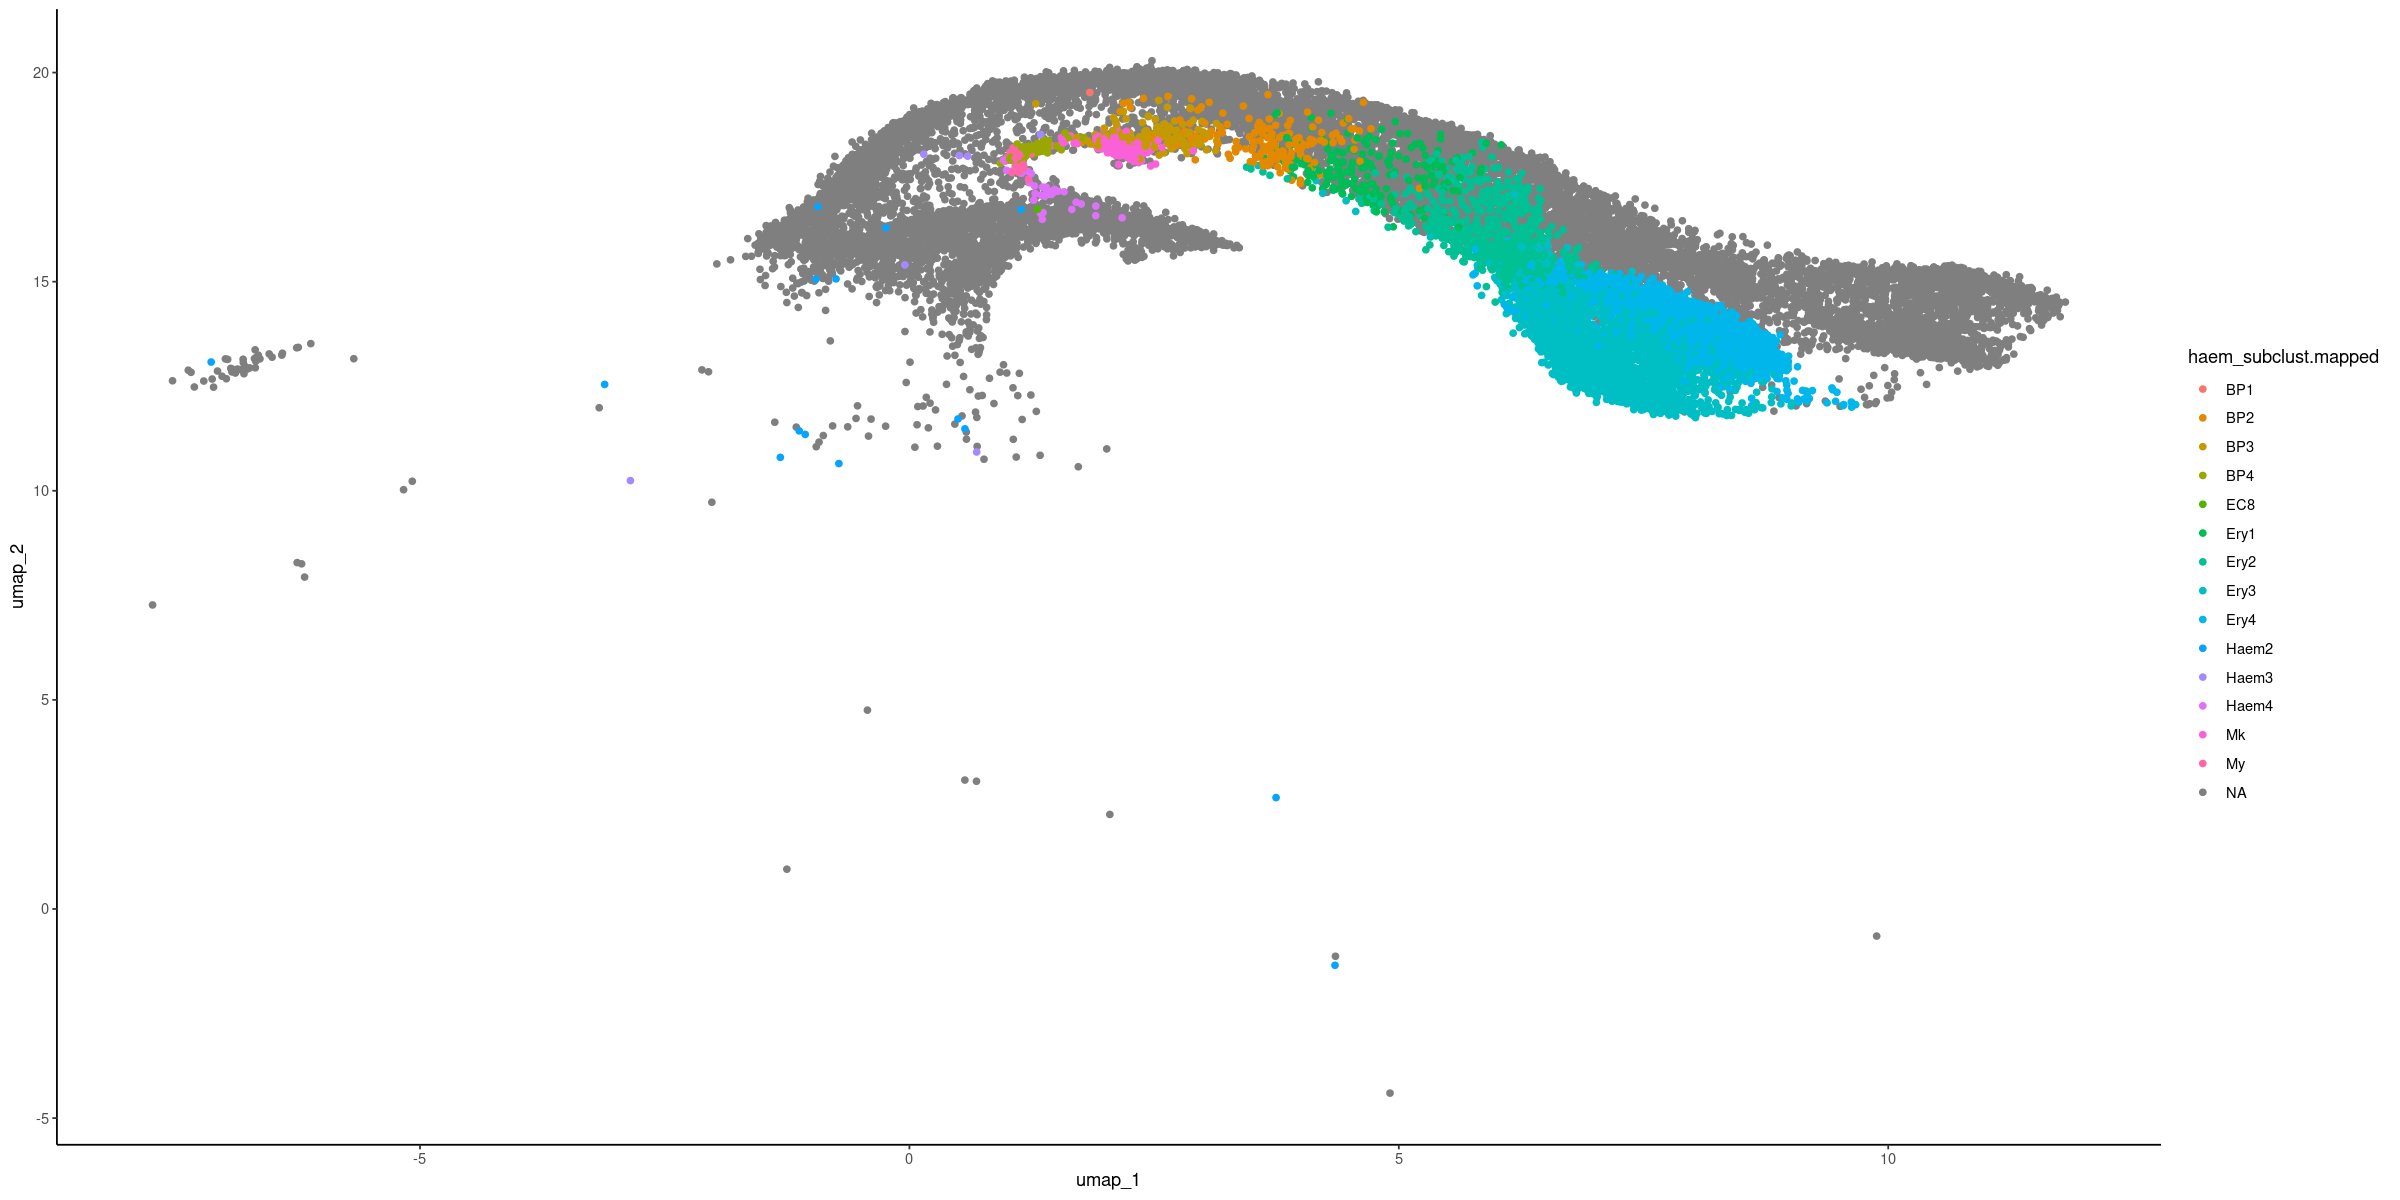

In [146]:
ggplot(haem_meta, aes(umap_1, umap_2, color=haem_subclust)) + geom_point() + theme_classic()
ggplot(haem_meta, aes(umap_1, umap_2, color=haem_subclust.mapped)) + geom_point() + theme_classic()

In [150]:
unique(big_meta$celltype)

[1] "Epiblast"                       "Caudal epiblast"               
 [3] "Rostral neurectoderm"           "Forebrain/Midbrain/Hindbrain"  
 [5] "Spinal cord"                    "Intermediate mesoderm"         
 [7] "Erythroid3"                     "Cardiomyocytes"                
 [9] "Mesenchyme"                     "ExE mesoderm"                  
[11] "NMP"                            "Gut"                           
[13] "Neural crest"                   "Allantois"                     
[15] "Pharyngeal mesoderm"            "Paraxial mesoderm"             
[17] "ExE ectoderm"                   "Haematoendothelial progenitors"
[19] "Erythroid2"                     "Surface ectoderm"              
[21] "ExE endoderm"                   "Endothelium"                   
[23] "Nascent mesoderm"               "Somitic mesoderm"              
[25] "Caudal neurectoderm"            "Caudal Mesoderm"               
[27] "Def. endoderm"                  "Blood progenitors 2"           
[29] "Visceral endoderm"              "Erythroid1"                    
[31] "Blood progenitors 1"            "Notochord"                     
[33] "PGC"                            "Mixed mesoderm"                
[35] "Primitive Streak"               "Parietal endoderm"             
[37] "Anterior Primitive Streak"      NA

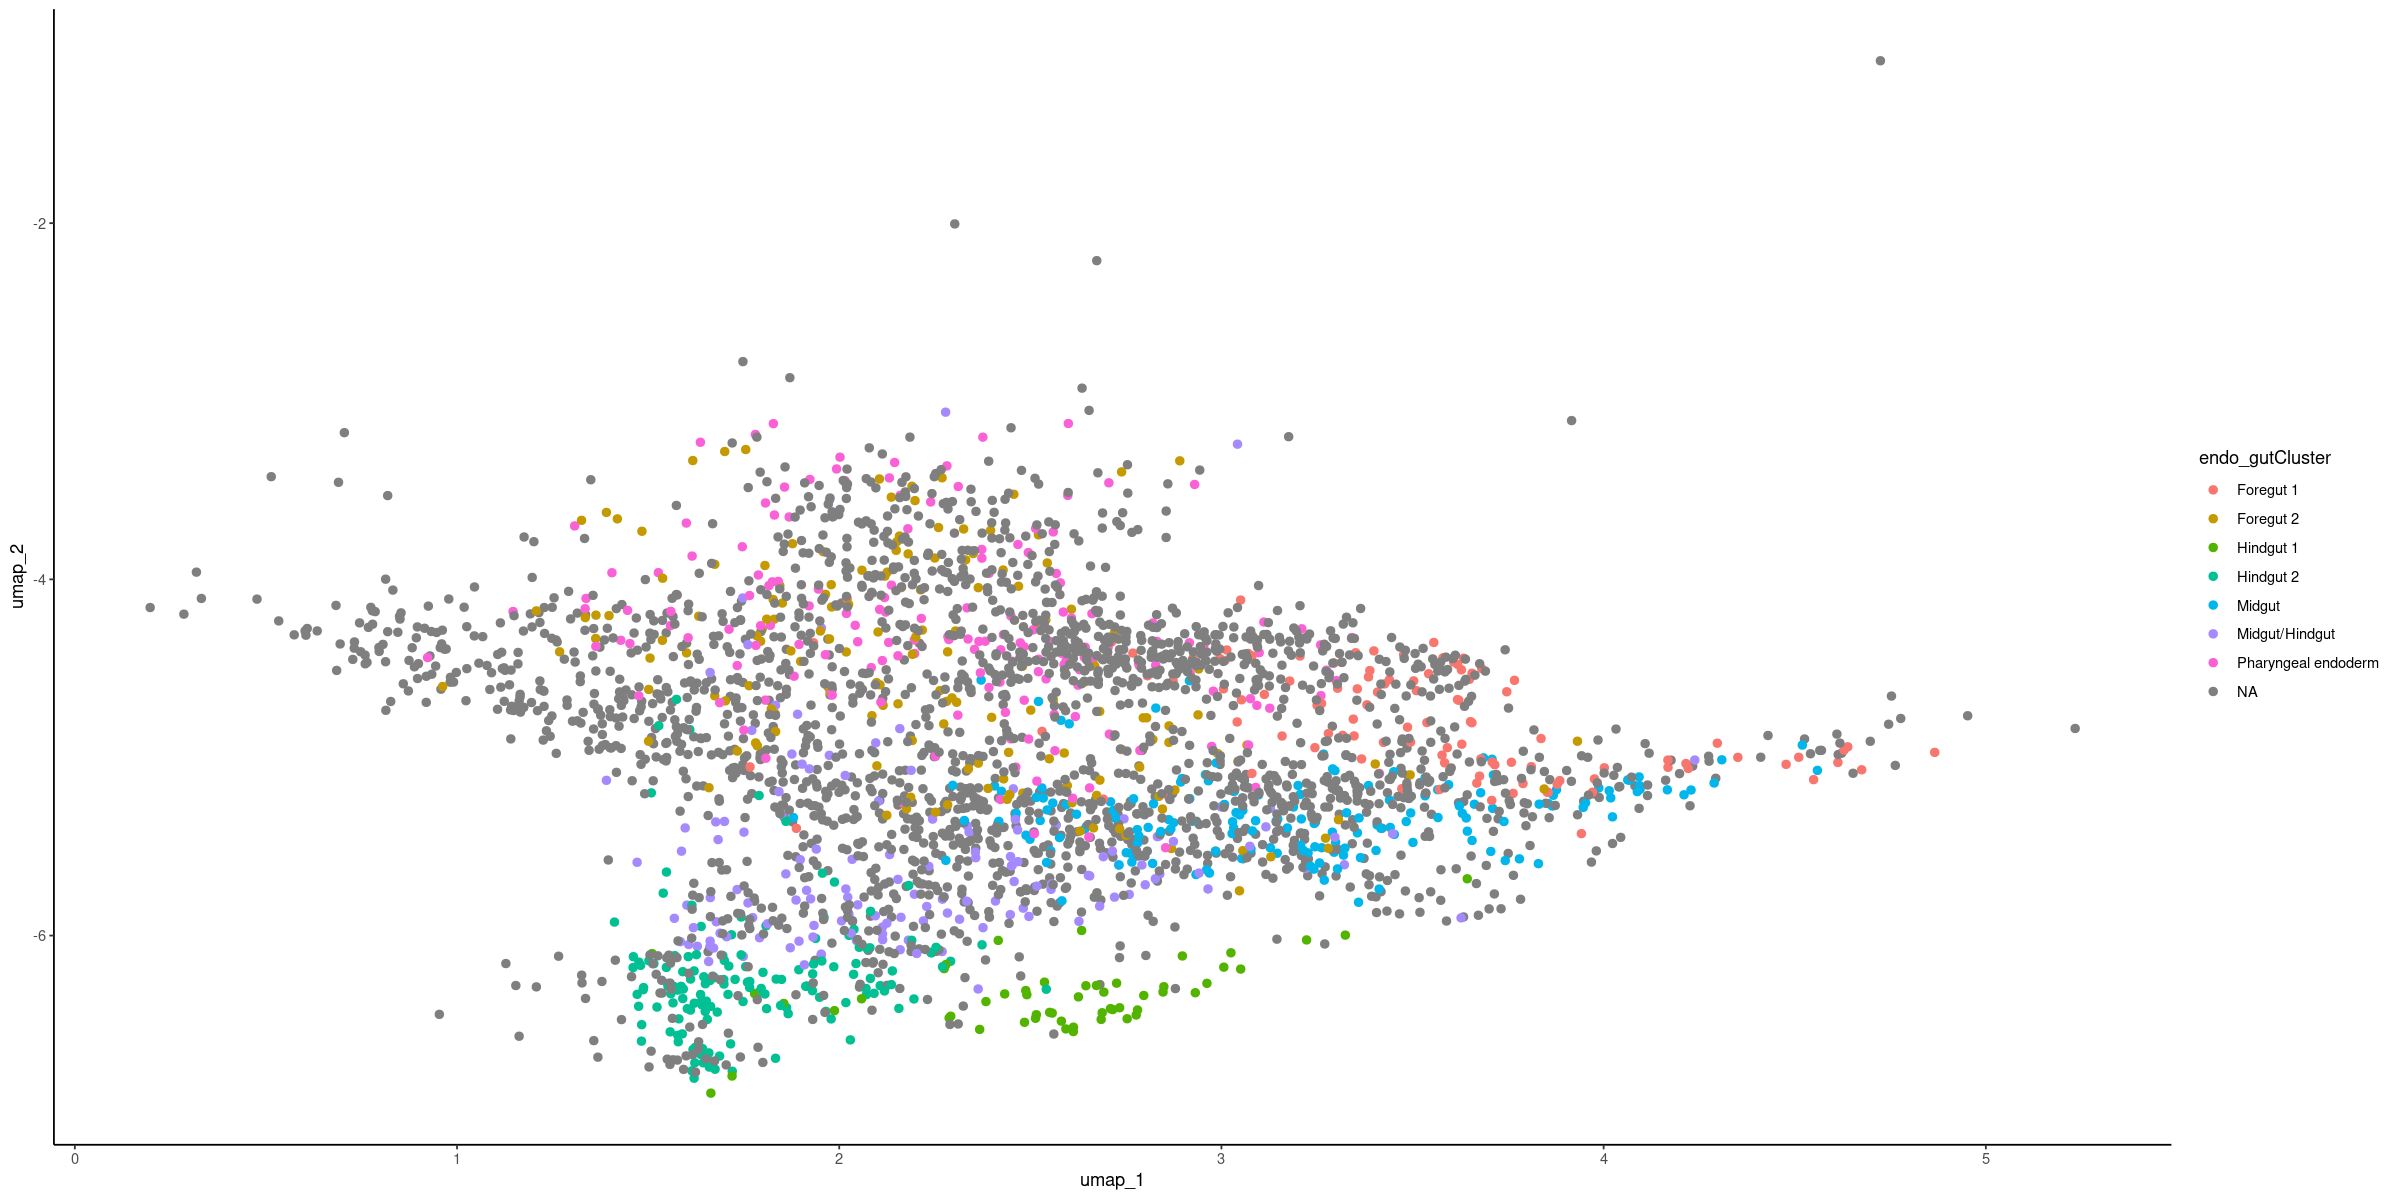

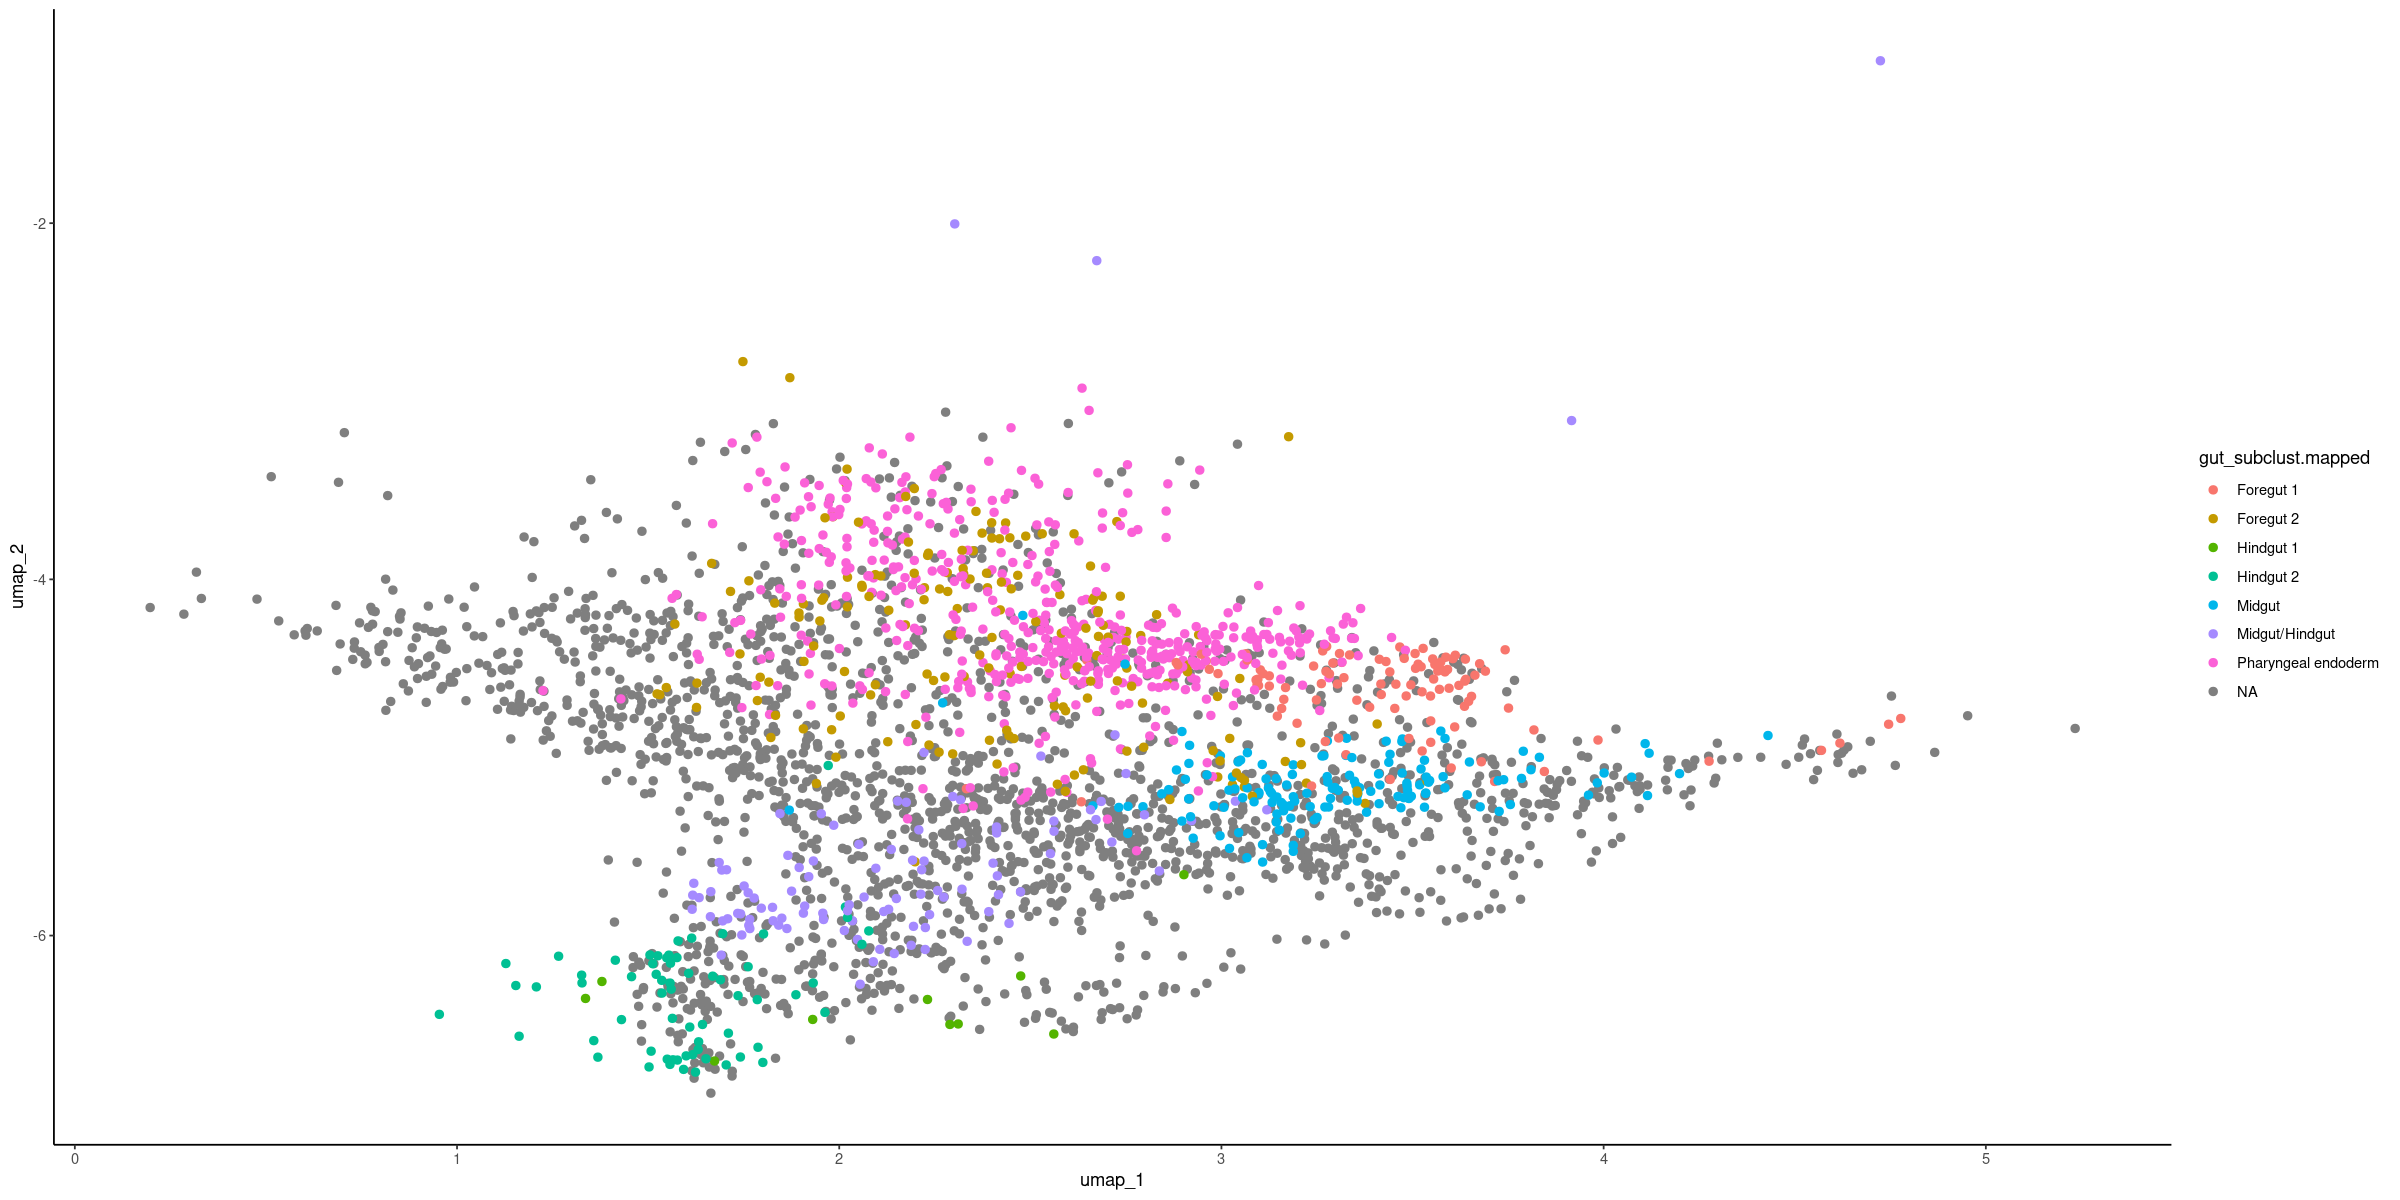

In [155]:
gut = big_meta %>% filter(umap_2 < 4 & celltype == 'Gut' | umap_2 < 4 &  celltype.mapped == 'Gut') 
ggplot(gut, aes(umap_1, umap_2, color=endo_gutCluster)) + geom_point(size = 2) + theme_classic()
ggplot(gut, aes(umap_1, umap_2, color=gut_subclust.mapped)) + geom_point(size = 2) + theme_classic()


### I/O

In [6]:
gut_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/gut/"
haem_folder = "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/haem/"
out_folder= "/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/data/"
umap_in = paste0(out_folder, 'big_umap.csv')
meta_in = paste0(out_folder, 'big_meta_mapping.tab')
plot_folder = '/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plots/'

source("/rds/project/bg200/rds-bg200-hphi-gottgens/users/bt392/mouse/Mixl1_KO/plot_colours.R") 
options(repr.plot.width = 10, repr.plot.height = 5)

In [7]:
gut = read.table(paste0(gut_folder,"big_meta_mapping.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
gut <- gut %>% filter(!is.na(gut$gut_subclust.mapped))
haem = read.table(paste0(haem_folder,"big_meta_mapping.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
haem <- haem %>% filter(!is.na(haem$haem_subclust.mapped))
meta = read.table(meta_in, header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")
meta$origin <- sapply(strsplit(meta$cell,"_"), `[`, 1) 
umap = read.csv(umap_in)

In [8]:
gut$tdTom = NULL
gut$tdTom[gut$sample %in% c('mixl_1', 'mixl_3', 'mixl_5')] <- "neg"
gut$tdTom[gut$sample %in% c('mixl_2', 'mixl_4', 'mixl_6')] <- "pos"

haem$tdTom = NULL
haem$tdTom[haem$sample %in% c('mixl_1', 'mixl_3', 'mixl_5')] <- "neg"
haem$tdTom[haem$sample %in% c('mixl_2', 'mixl_4', 'mixl_6')] <- "pos"

In [9]:
gut2 = gut %>% select(cell, gut_subclust.mapped)
haem2 = haem %>% select(cell, haem_subclust.mapped)
meta = merge(meta, umap, by='cell')
meta = merge(meta, gut2, by='cell', all.x=TRUE)
meta = merge(meta, haem2, by='cell', all.x=TRUE)

In [10]:
#define functions

boot = function(df, k){
    big = df %>% select(celltype.mapped, tomato) %>% distinct() %>% arrange(celltype.mapped)
    colnames(big) = c('Var1', 'Var2')
    
    rownames(df) = df$cell
    
    # Caclulate mean from all data before bootstrapping
    pdf_mean = table(df$celltype.mapped, df$tomato)
    pdf_mean = as.data.frame(sweep(pdf_mean, 2, colSums(pdf_mean), "/"))
    colnames(pdf_mean) = c('Var1', 'Var2', 'mean') # renamed to mean to make compatible with other code
    
    # Calculate SD via bootstrapping
    for(i in 1:k){ # iterate k times
        subset_cells = sample(df$cell, replace = TRUE) # random sampling with replacements
        subset = df[subset_cells,]
        pdf1 = table(subset$celltype.mapped, subset$tomato)
        pdf1 = as.data.frame(sweep(pdf1, 2, colSums(pdf1), "/"))
     #   pdf1$Freq = pdf1$Freq + 0.00001
        colnames(pdf1) = c('Var1', 'Var2', paste0('Freq_', i))
        big = merge(big, pdf1, by=c('Var1', 'Var2'), all.x=TRUE)
    }
    big[is.na(big)] <- 0.00001 # NA = 0
    long = gather(big, sample, frequency, Freq_1:colnames(big[length(big)]), -Var1, -Var2)
    sd = long %>% group_by(Var1, Var2) %>% summarize(sd = sd(frequency, na.rm = TRUE))

    mean_sd = merge(pdf_mean, sd, by=c('Var1', 'Var2'), all.x=TRUE) # merge mean with sd
    
    big = df %>% select(celltype.mapped, tomato) %>% distinct() %>% arrange(celltype.mapped)
    colnames(big) = c('Var1', 'Var2')
    mean_sd = merge(big, mean_sd, by=c('Var1', 'Var2'), all.x=TRUE)
    mean_sd[is.na(mean_sd)] <- 0
    
    return(mean_sd)
   # return(big)
    
}

plot_freq = function(df, title){
  ggplot(data = df, mapping = aes(x = Var1, y = mean, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("TRUE" = "red", "FALSE" = "black"), 
                    labels = c("TRUE" = "Tomato+", "FALSE" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas celltype", y = "Fraction of cells") +
  ggtitle(paste0(title, ' subcluster frequencies')) +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",text = element_text(size = 20), 
        axis.title.x = element_blank()) +
  geom_errorbar(aes(ymin=mean-sd, ymax=mean+sd), width=.4,
                 position=position_dodge(.9)) +
  scale_x_discrete(breaks = unique(df$Var1)[order(unique(df$Var1))])
}

ratio = function(df, original){
    means = df %>% select(Var1, Var2, mean)
    ratio_mean = spread(means, Var2, mean)
    colnames(ratio_mean) = c('Var1', 'host', 'inject')
    ratio_mean$ratio = log2(ratio_mean$inject / ratio_mean$host)
    ratio_mean_bu = ratio_mean
    ratio_mean = ratio_mean %>% select(Var1, ratio)

    error = df %>% select(Var1, Var2, sd)
    ratio_error = spread(error, Var2, sd)
    colnames(ratio_error) = c('Var1', 'host', 'inject')
    ratio_error$sd = ratio_mean$ratio*sqrt((ratio_error$inject/ratio_mean_bu$inject)^2 + (ratio_error$host/ratio_mean_bu$host)^2)
    #ratio_error$sd = log(ratio_error$inject / ratio_error$host)
    ratio_error = ratio_error %>% select(Var1, sd)

    original$count = 1
    counts = original %>% group_by(celltype.mapped) %>% summarize(count = sum(count))
    colnames(counts) = c('Var1', 'ncells')
    ratio_error = merge(ratio_error, counts, by='Var1')
    ratio_error$sd = ratio_error$sd / sqrt(ratio_error$ncells) # calculate SEM from propagated error
    
    ratio_final = merge(ratio_mean, ratio_error, by='Var1')
    
#     big = KO %>% select(celltype.mapped) %>% distinct() %>% arrange(celltype.mapped)
#     colnames(big) = c('Var1')
#     ratio_final = merge(big, ratio_final, by=c('Var1'), all.x=TRUE)
#     ratio_final[is.na(ratio_final)] <- 0 # NA = 0
    
    return(ratio_final)
}

plot_ratio_gut = function(df, title){
    ggplot(data = df, mapping = aes(x = Var1, y = ratio, fill=Var1)) +
      geom_bar(stat = "identity", position = "dodge", color='black') +
      labs(x = "Atlas celltype", y = "log2(injected/host)") +
      ggtitle(paste0(title, ' subcluster fold change')) +
      theme_classic() +
      theme(axis.text.x = element_text(angle = -30, hjust = 0),
            legend.position = "none", text = element_text(size = 20), 
            axis.title.x = element_blank()) +
       geom_errorbar(aes(ymin=ratio-sd, ymax=ratio+sd), width=.4,
                     position=position_dodge(.9)) +
      scale_fill_manual(values = c(gut_colours)) +
      geom_hline(yintercept=0)
}

plot_ratio_haem = function(df, title){
    ggplot(data = df, mapping = aes(x = Var1, y = ratio, fill=Var1)) +
      geom_bar(stat = "identity", position = "dodge", color='black') +
      labs(x = "Atlas celltype", y = "log2(injected/host)") +
      ggtitle(paste0(title, ' subcluster fold change')) +
      theme_classic() +
      theme(axis.text.x = element_text(angle = -30, hjust = 0),
            legend.position = "none", text = element_text(size = 20), 
            axis.title.x = element_blank()) +
       geom_errorbar(aes(ymin=ratio-sd, ymax=ratio+sd), width=.4,
                     position=position_dodge(.9)) +
      scale_fill_manual(values = c(haem_colours)) +
      geom_hline(yintercept=0) +
      scale_x_discrete(breaks = unique(df$Var1)[order(unique(df$Var1))])
}

### Haem

In [11]:
haem$celltype.mapped = haem$haem_subclust.mapped
haem$tomato = haem$tdTom

haem$tomato =  ifelse(haem$tomato == 'pos',TRUE, FALSE)

In [14]:
head(haem)

,cell,sample,stage,barcode,sequencing.batch,stripped,doublet,theiler,doub.density,cluster,⋯,endo_gutDPT,endo_gutCluster,weight,stage.mapped,celltype.mapped,closest.cell,haem_subclust.mapped,tdTom,tomato,count
,<chr>,<chr>,<chr>,<chr>,<int>,<lgl>,<lgl>,<chr>,<dbl>,<int>,⋯,<lgl>,<lgl>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<lgl>,<dbl>
1,chim_cell_2,mixl_1,E8.5,AAACCCAAGGGACTGT,1,FALSE,FALSE,NA,NA,NA,⋯,NA,NA,139333,E8.5,Ery3,atlas_cell_39819,Ery3,neg,FALSE,1
2,chim_cell_8,mixl_1,E8.5,AAACCCATCAGCCTTC,1,FALSE,FALSE,NA,NA,NA,⋯,NA,NA,139339,E8.5,Ery3,atlas_cell_37672,Ery3,neg,FALSE,1
3,chim_cell_10,mixl_1,E8.5,AAACCCATCATTGGTG,1,FALSE,FALSE,NA,NA,NA,⋯,NA,NA,139341,E8.5,Ery3,atlas_cell_136027,Ery3,neg,FALSE,1
4,chim_cell_12,mixl_1,E8.5,AAACGAAAGGCCTGAA,1,FALSE,FALSE,NA,NA,NA,⋯,NA,NA,139343,E8.5,Ery3,atlas_cell_100974,Ery3,neg,FALSE,1
5,chim_cell_13,mixl_1,E8.5,AAACGAAGTGTAAACA,1,FALSE,FALSE,NA,NA,NA,⋯,NA,NA,139344,E8.5,Ery3,atlas_cell_136832,Ery3,neg,FALSE,1
6,chim_cell_18,mixl_1,E8.5,AAACGCTCAATGTTGC,1,FALSE,FALSE,NA,NA,NA,⋯,NA,NA,139349,E8.5,Ery4,atlas_cell_40941,Ery4,neg,FALSE,1


In [13]:
# exclude extremely low cell nr
haem$count = 1
counts = haem %>% group_by(celltype.mapped) %>% summarize(count = sum(count))
celltypes.keep = counts %>% filter(count > 5) %>% .$celltype.mapped

haem_mapping = boot(haem, 1000)
haem_mapping = haem_mapping %>% filter(Var1 %in% celltypes.keep)
haem_ratio = ratio(haem_mapping, haem)


`summarise()` ungrouping output (override with `.groups` argument)

`summarise()` regrouping output by 'Var1' (override with `.groups` argument)

`summarise()` ungrouping output (override with `.groups` argument)



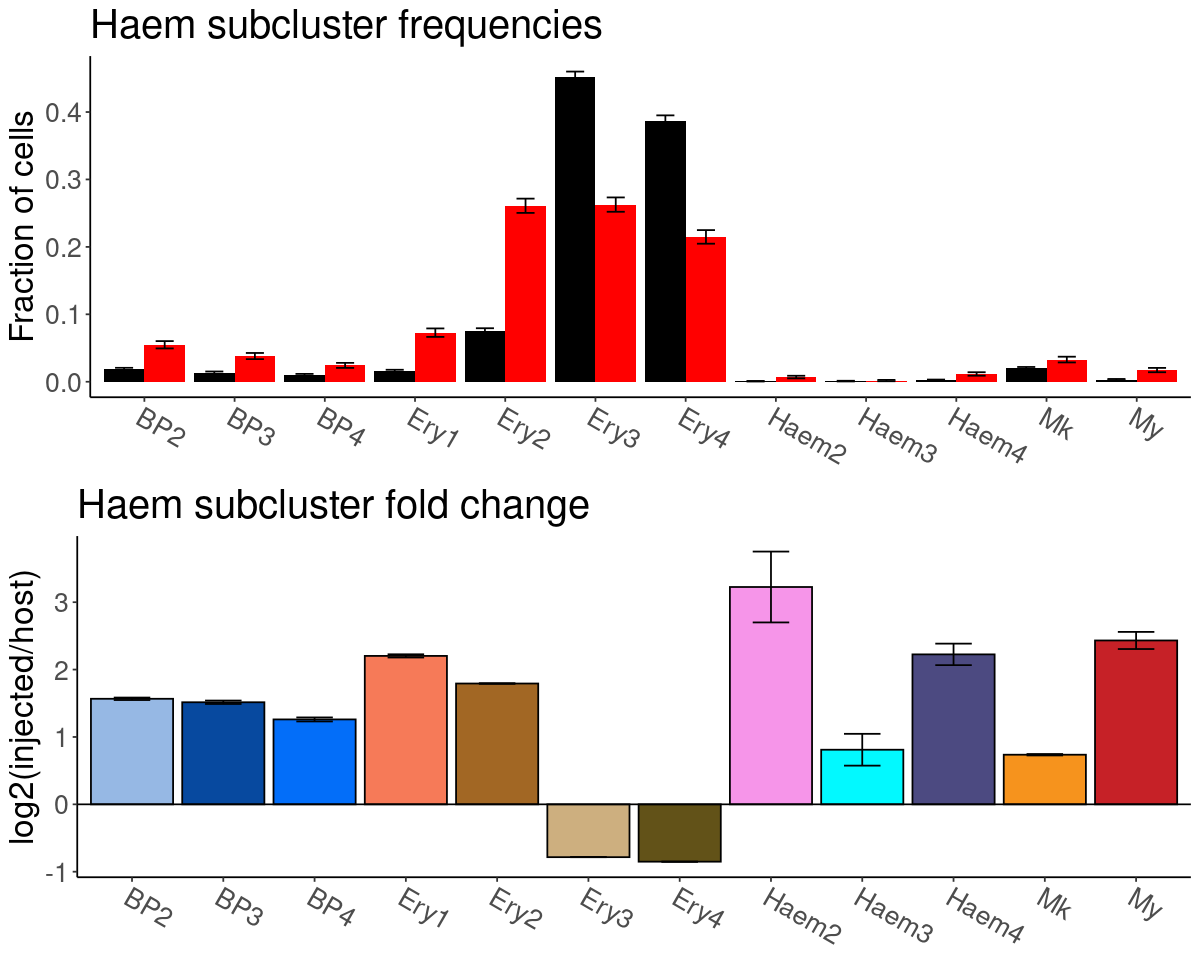

In [15]:
p1 = plot_freq(haem_mapping, 'Haem')
p2 = plot_ratio_haem(haem_ratio, 'Haem')

options(repr.plot.width = 10, repr.plot.height = 8)
plot_grid(p1, p2, nrow = 2)

In [16]:
pdf(paste0(plot_folder, "distribution_haem.pdf"), height=15, width=15)
    plot_grid(p1, p2, nrow = 2)
dev.off()

png 
  2

In [10]:
haem_cells = meta %>% filter(haem_subclust != 'NA' | haem_subclust.mapped != 'NA') %>% .$cell
haem = meta %>% filter(cell %in% haem_cells & umap_2 > 11)
haem_atlas = haem %>% filter(origin == 'atlas')
haem_chim = haem %>% filter(origin == 'chim')
p1 = ggplot(haem_chim, aes(umap_1, umap_2, color=haem_subclust.mapped)) + 
    scale_colour_manual(values = haem_colours, labels = haem_labels, name = "haem subcluster") +
    geom_point(color = 'grey',  size=0.5, alpha = 0.3) + 
    geom_point(data = haem_atlas, aes(color = haem_subclust), size=0.5, alpha = 0.3) +
    theme_void() + theme(legend.position = 'none',plot.title = element_text(size=22))  +
    ggtitle('haem subclusters - Atlas')

p2 = ggplot(haem_atlas, aes(umap_1, umap_2, color=haem_subclust)) + 
    scale_colour_manual(values = haem_colours, labels = haem_labels, name = "haem subcluster") +
    geom_point(color = 'grey',  size=0.5, alpha = 0.3) + 
    geom_point(data = haem_chim, aes(color = haem_subclust.mapped), size=0.5, alpha = 0.3) +
    theme_void() + theme(legend.position = 'none',plot.title = element_text(size=22))+
    ggtitle('- Chimaera')

p_legend = ggplot(haem, aes(umap_1, umap_2, color=haem_subclust)) + 
    scale_colour_manual(values = haem_colours, labels = haem_labels, name = "haem subcluster") + 
    geom_point(size=5) + theme_classic() + theme(text = element_text(size = 20))

Warning message:
“Removed 5776 rows containing missing values (geom_point).”


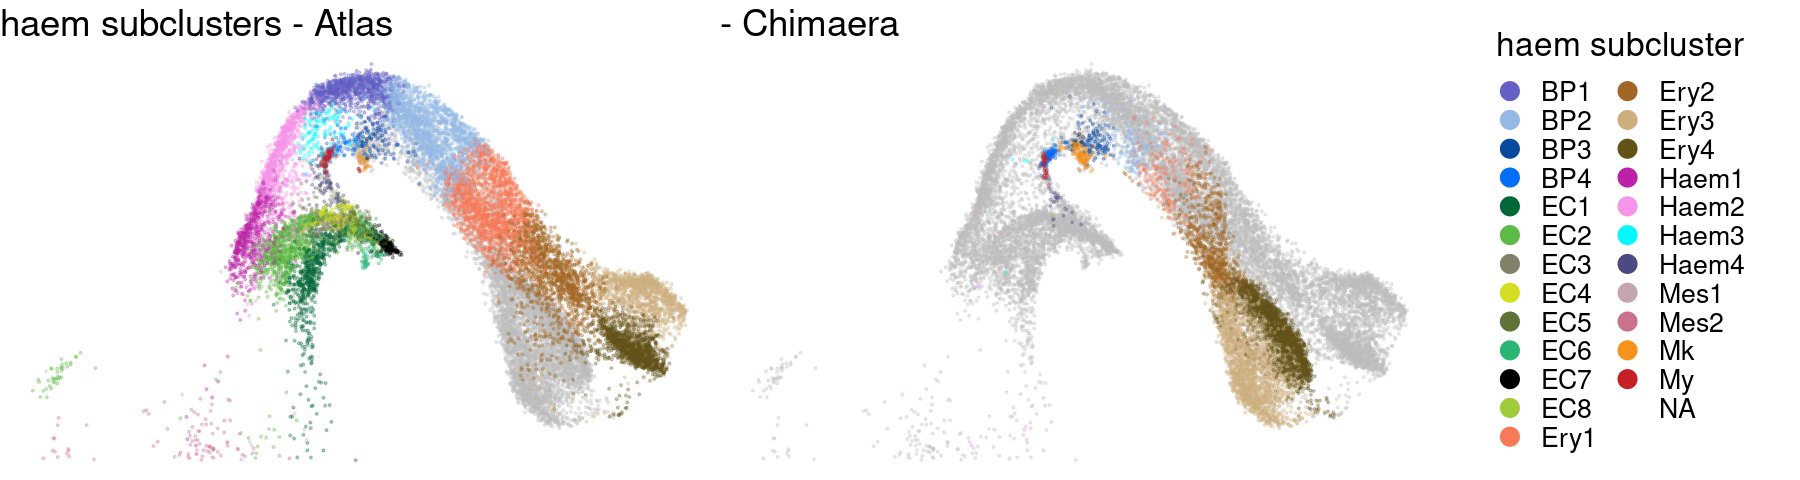

In [11]:
options(repr.plot.width = 15, repr.plot.height = 4)
plot_grid(p1, p2, get_legend(p_legend), rel_widths = c(0.4, 0.4, 0.2), ncol = 3)

In [12]:
png(paste0(plot_folder, "haem_subclusters.png"), width = 1500, height = 500)
    plot_grid(p1, p2, get_legend(p_legend), rel_widths = c(0.4, 0.4, 0.2), ncol = 3)
dev.off()

Warning message:
“Removed 5776 rows containing missing values (geom_point).”


png 
  2

### Gut

In [28]:
haem$count = 1
haem %>% group_by(haem_subclust.mapped,tomato) %>% summarize(sum = sum(count))

`summarise()` regrouping output by 'haem_subclust.mapped' (override with `.groups` argument)



haem_subclust.mapped,tomato,sum
<chr>,<lgl>,<dbl>
BP1,TRUE,1
BP2,FALSE,75
BP2,TRUE,95
BP3,FALSE,54
BP3,TRUE,66
BP4,FALSE,41
BP4,TRUE,42
EC8,TRUE,1
Ery1,FALSE,64


In [17]:
plot_freq = function(df, title){
  ggplot(data = df, mapping = aes(x = Var1, y = mean, fill = Var2)) +
  geom_bar(stat = "identity", position = "dodge") +
  scale_fill_manual(values = c("TRUE" = "red", "FALSE" = "black"), 
                    labels = c("TRUE" = "Tomato+", "FALSE" = "Tomato-"),
                    name = "") +
  labs(x = "Atlas celltype", y = "Fraction of cells") +
  ggtitle(paste0(title, ' subcluster frequencies')) +
  theme_classic() +
  theme(axis.text.x = element_text(angle = -30, hjust = 0),
        legend.position = "none",text = element_text(size = 20), 
        axis.title.x = element_blank()) +
  geom_errorbar(aes(ymin=mean-sd, ymax=mean+sd), width=.4,
                 position=position_dodge(.9))
}

In [18]:
gut$celltype.mapped = gut$gut_subclust.mapped
gut$tomato = gut$tdTom

gut$tomato =  ifelse(gut$tomato == 'pos',TRUE, FALSE)

In [19]:
gut_mapping = boot(gut, 1000)
hind = data.frame('Var1'='Hindgut 1', 'Var2'=TRUE, 'mean' = 0, 'sd' = 0)
gut_mapping = rbind(gut_mapping, hind)
gut_ratio = ratio(gut_mapping, gut)


`summarise()` regrouping output by 'Var1' (override with `.groups` argument)

`summarise()` ungrouping output (override with `.groups` argument)



In [20]:
gut_mapping$Var1 = factor(gut_mapping$Var1, levels = c('Pharyngeal endoderm', 'Foregut 1','Foregut 2','Midgut', 'Midgut/Hindgut','Hindgut 1','Hindgut 2'))
gut_ratio$Var1 = factor(gut_ratio$Var1, levels = c('Pharyngeal endoderm', 'Foregut 1','Foregut 2','Midgut', 'Midgut/Hindgut','Hindgut 1','Hindgut 2'))

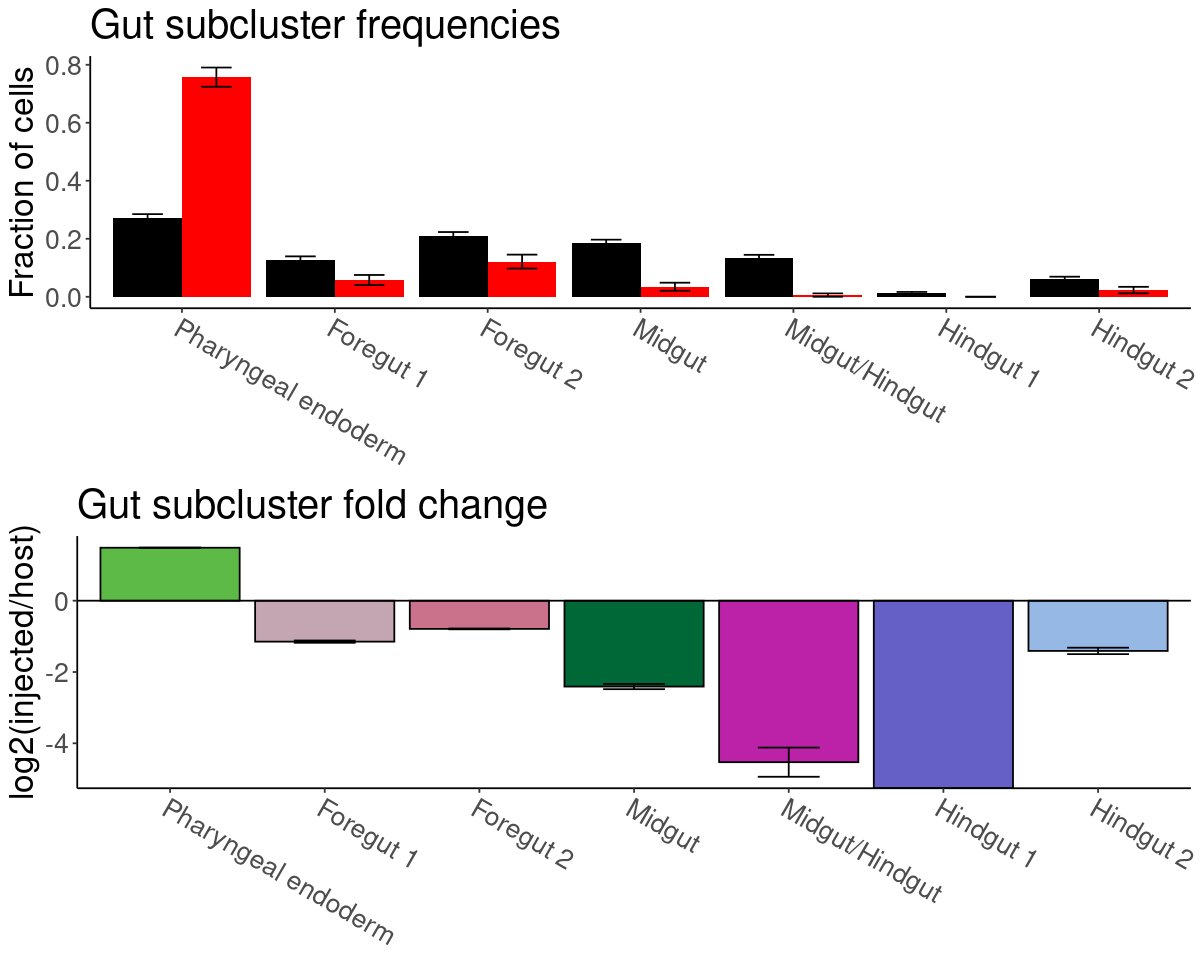

In [21]:

p1 = plot_freq(gut_mapping, 'Gut') 
p2 = plot_ratio_gut(gut_ratio, 'Gut')

options(repr.plot.width = 10, repr.plot.height = 8)
plot_grid(p1, p2, nrow = 2)

In [23]:
pdf(paste0(plot_folder, "distribution_gut.pdf"), height=15, width=15)
    plot_grid(p1, p2, nrow = 2)
dev.off()

png 
  2

In [13]:
meta$gut_subclust = meta$endo_gutCluster

In [14]:
unique(meta$gut_subclust)

[1] NA                    "Midgut"              "Midgut/Hindgut"     
[4] "Hindgut 2"           "Pharyngeal endoderm" "Foregut 2"          
[7] "Foregut 1"           "Hindgut 1"

In [15]:
gut_cells = meta %>% filter(gut_subclust != 'NA' | gut_subclust.mapped != 'NA') %>% .$cell
gut = meta %>% filter(cell %in% gut_cells & umap_2 < 0 & umap_1 > 0)
gut_atlas = gut %>% filter(origin == 'atlas')
gut_chim = gut %>% filter(origin == 'chim')
p1 = ggplot(gut_chim, aes(umap_1, umap_2, color=gut_subclust.mapped)) + 
    scale_colour_manual(values = gut_colours, labels = gut_labels, name = "gut subcluster") +
    geom_point(color = 'grey',  size=2, alpha = 0.5) + 
    geom_point(data = gut_atlas, aes(color = gut_subclust), size=2, alpha = 0.5) +
    theme_void() + theme(legend.position = 'none',plot.title = element_text(size=22)) +
    ggtitle('gut subclusters - Atlas')

p2 = ggplot(gut_atlas, aes(umap_1, umap_2, color=gut_subclust)) + 
    scale_colour_manual(values = gut_colours, labels = gut_labels, name = "gut subcluster") +
    geom_point(color = 'grey',  size=2, alpha = 0.5) + 
    geom_point(data = gut_chim, aes(color = gut_subclust.mapped), size=2, alpha = 0.5) +
    theme_void() + theme(legend.position = 'none',plot.title = element_text(size=22))+
    ggtitle('- Chimaera')

p_legend = ggplot(gut, aes(umap_1, umap_2, color=gut_subclust)) + 
    scale_colour_manual(values = gut_colours, labels = gut_labels, name = "gut subcluster") + 
    geom_point(size=5) + theme_classic() + theme(text = element_text(size = 20))

Warning message:
“Removed 1099 rows containing missing values (geom_point).”


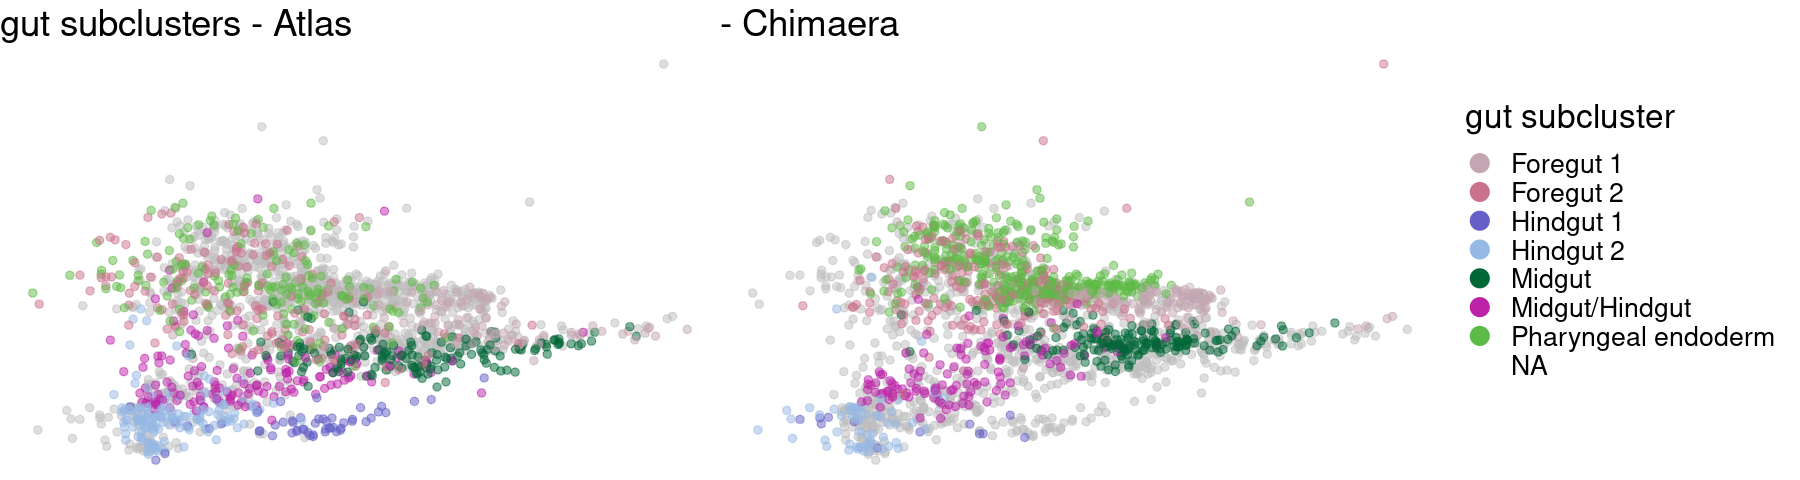

In [16]:
options(repr.plot.width = 15, repr.plot.height = 4)
plot_grid(p1, p2, get_legend(p_legend), rel_widths = c(0.4, 0.4, 0.2), ncol = 3)

In [118]:
png(paste0(plot_folder, "gut_subclusters.png"), width = 1500, height = 500)
    plot_grid(p1, p2, get_legend(p_legend), rel_widths = c(0.4, 0.4, 0.2), ncol = 3)
dev.off()

Warning message:
“Removed 1099 rows containing missing values (geom_point).”


png 
  2

In [29]:
gut = read.table(paste0(gut_folder,"big_meta_mapping.tab"), header = TRUE, sep = "\t", stringsAsFactors = FALSE, comment.char = "$")


In [31]:
gut$count = 1 
gut %>% group_by(endo_gutCluster) %>% summarize(sum = sum(count))

`summarise()` ungrouping output (override with `.groups` argument)



endo_gutCluster,sum
<chr>,<dbl>
Foregut 1,112
Foregut 2,162
Hindgut 1,53
Hindgut 2,148
Midgut,161
Midgut/Hindgut,144
Pharyngeal endoderm,167
NA,1102


In [32]:
nrow(gut)

[1] 2049